# Ames Housing Price Prediction

## Project Overview

This project focuses on predicting house sale prices using the Ames Housing dataset and machine learning regression techniques.

The project covers data exploration, data preprocessing, feature engineering, model training, evaluation, and model interpretation.


![Ames Housing Dataset](./images.jfif)

In [534]:
from sklearn.datasets import fetch_openml

In [535]:
data = fetch_openml(
    data_id=41211,
    as_frame=True
)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\datasets\_openml.py:1035: UserWarning: Version 1 of dataset ames-housing is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/20649135/ames-housing.arff
  warn(


In [536]:
df = data.frame
df

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,37,7937,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,...,Good_Privacy,None,0,3,2006,WD,Normal,142500,-93.604776,41.988964
2926,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,0,8885,Pave,No_Alley_Access,Slightly_Irregular,Low,AllPub,Inside,...,Minimum_Privacy,None,0,6,2006,WD,Normal,131000,-93.602680,41.988314
2927,Split_Foyer,Residential_Low_Density,62,10441,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,Shed,700,7,2006,WD,Normal,132000,-93.606847,41.986510
2928,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,77,10010,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,No_Fence,None,0,4,2006,WD,Normal,170000,-93.600190,41.990921


In [537]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [538]:
df.head()

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899


In [539]:
df.shape

(2930, 81)

In [540]:
df.columns

Index(['MS_SubClass', 'MS_Zoning', 'Lot_Frontage', 'Lot_Area', 'Street',
       'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config',
       'Land_Slope', 'Neighborhood', 'Condition_1', 'Condition_2', 'Bldg_Type',
       'House_Style', 'Overall_Qual', 'Overall_Cond', 'Year_Built',
       'Year_Remod_Add', 'Roof_Style', 'Roof_Matl', 'Exterior_1st',
       'Exterior_2nd', 'Mas_Vnr_Type', 'Mas_Vnr_Area', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_SF_1', 'BsmtFin_Type_2', 'BsmtFin_SF_2',
       'Bsmt_Unf_SF', 'Total_Bsmt_SF', 'Heating', 'Heating_QC', 'Central_Air',
       'Electrical', 'First_Flr_SF', 'Second_Flr_SF', 'Low_Qual_Fin_SF',
       'Gr_Liv_Area', 'Bsmt_Full_Bath', 'Bsmt_Half_Bath', 'Full_Bath',
       'Half_Bath', 'Bedroom_AbvGr', 'Kitchen_AbvGr', 'Kitchen_Qual',
       'TotRms_AbvGrd', 'Functional', 'Fireplaces', 'Fireplace_Qu',
       'Garage_Type', 'Garage_Finish', 'Garage_Cars', 'G

In [541]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   MS_SubClass         2930 non-null   category
 1   MS_Zoning           2930 non-null   category
 2   Lot_Frontage        2930 non-null   int64   
 3   Lot_Area            2930 non-null   int64   
 4   Street              2930 non-null   category
 5   Alley               2930 non-null   category
 6   Lot_Shape           2930 non-null   category
 7   Land_Contour        2930 non-null   category
 8   Utilities           2930 non-null   category
 9   Lot_Config          2930 non-null   category
 10  Land_Slope          2930 non-null   category
 11  Neighborhood        2930 non-null   category
 12  Condition_1         2930 non-null   category
 13  Condition_2         2930 non-null   category
 14  Bldg_Type           2930 non-null   category
 15  House_Style         2930 non-null   category
 16 

In [542]:
df.describe()

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.647782,10147.921843,1971.356314,1984.266553,101.096928,4.177474,49.705461,559.071672,1051.255631,1159.557679,...,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068,-93.642897,42.034482
std,33.499441,7880.017759,30.245361,20.860286,178.634545,2.233372,169.142089,439.540571,440.968018,391.890885,...,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357,0.025700,0.018410
min,0.000000,1300.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000,-93.693153,41.986498
25%,43.000000,7440.250000,1954.000000,1965.000000,0.000000,3.000000,0.000000,219.000000,793.000000,876.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000,-93.660217,42.022088
50%,63.000000,9436.500000,1973.000000,1993.000000,0.000000,3.000000,0.000000,465.500000,990.000000,1084.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000,-93.641806,42.034662
75%,78.000000,11555.250000,2001.000000,2004.000000,162.750000,7.000000,0.000000,801.750000,1301.500000,1384.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000,-93.622113,42.049853
max,313.000000,215245.000000,2010.000000,2010.000000,1600.000000,7.000000,1526.000000,2336.000000,6110.000000,5095.000000,...,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000,-93.577427,42.063388


In [543]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numerical_cols]

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
0,141,31770,1960,1960,112,2,0,441,1080,1656,...,0,0,0,0,0,5,2010,215000,-93.619754,42.054035
1,80,11622,1961,1961,0,6,144,270,882,896,...,0,0,120,0,0,6,2010,105000,-93.619756,42.053014
2,81,14267,1958,1958,108,1,0,406,1329,1329,...,0,0,0,0,12500,6,2010,172000,-93.619387,42.052659
3,93,11160,1968,1968,0,1,0,1045,2110,2110,...,0,0,0,0,0,4,2010,244000,-93.617320,42.051245
4,74,13830,1997,1998,0,3,0,137,928,928,...,0,0,0,0,0,3,2010,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37,7937,1984,1984,0,3,0,184,1003,1003,...,0,0,0,0,0,3,2006,142500,-93.604776,41.988964
2926,0,8885,1983,1983,0,2,324,239,864,902,...,0,0,0,0,0,6,2006,131000,-93.602680,41.988314
2927,62,10441,1992,1992,0,3,0,575,912,970,...,0,0,0,0,700,7,2006,132000,-93.606847,41.986510
2928,77,10010,1974,1975,0,1,123,195,1389,1389,...,0,0,0,0,0,4,2006,170000,-93.600190,41.990921


In [544]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

df[categorical_cols]

,MS_SubClass,MS_Zoning,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,...,Garage_Type,Garage_Finish,Garage_Qual,Garage_Cond,Paved_Drive,Pool_QC,Fence,Misc_Feature,Sale_Type,Sale_Condition
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Partial_Pavement,No_Pool,No_Fence,None,WD,Normal
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,No_Fence,Gar2,WD,Normal
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal
4,Two_Story_1946_and_Newer,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,...,Detchd,Unf,Typical,Typical,Paved,No_Pool,Good_Privacy,None,WD,Normal
2926,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Low,AllPub,Inside,Mod,Mitchell,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2927,Split_Foyer,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,Mitchell,...,No_Garage,No_Garage,No_Garage,No_Garage,Paved,No_Pool,Minimum_Privacy,Shed,WD,Normal
2928,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Mod,Mitchell,...,Attchd,RFn,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal


> ### 🏠 Ames Housing Price Prediction
>
> **🎯 Target:** `SalePrice`  
> **🧩 Problem:** `Regression`  
> **🚀 Goal:** Predict house sale prices

## 📋 Feature Dictionary | فرهنگ ویژگی‌ها

| Feature              | English Description                             | توضیح فارسی                                     |
| -------------------- | ----------------------------------------------- | ----------------------------------------------- |
| `MS_SubClass`        | Building class                                  | کلاس ساختمان                                    |
| `MS_Zoning`          | General zoning classification                   | طبقه‌بندی کلی منطقه‌بندی                        |
| `Lot_Frontage`       | Linear feet of street connected to property     | طول برِ ملک متصل به خیابان                      |
| `Lot_Area`           | Lot size in square feet                         | مساحت زمین بر حسب فوت مربع                      |
| `Street`             | Type of road access                             | نوع دسترسی به خیابان                            |
| `Alley`              | Type of alley access                            | نوع دسترسی به کوچه                              |
| `Lot_Shape`          | General shape of property                       | شکل کلی زمین                                    |
| `Land_Contour`       | Flatness of the property                        | وضعیت پستی‌وبلندی زمین                          |
| `Utilities`          | Type of utilities available                     | نوع امکانات و خدمات شهری                        |
| `Lot_Config`         | Lot configuration                               | نوع قرارگیری و پیکربندی زمین                    |
| `Land_Slope`         | Slope of property                               | شیب زمین                                        |
| `Neighborhood`       | Physical location within Ames                   | محله ملک                                        |
| `Condition_1`        | Proximity to main roads or nearby features      | نزدیکی به جاده‌های اصلی یا ویژگی‌های اطراف      |
| `Condition_2`        | Secondary proximity to roads or nearby features | نزدیکی ثانویه به جاده‌ها یا ویژگی‌های اطراف     |
| `Bldg_Type`          | Type of dwelling                                | نوع ساختمان مسکونی                              |
| `House_Style`        | Style of dwelling                               | سبک ساختمان                                     |
| `Overall_Qual`       | Overall material and finish quality             | کیفیت کلی مصالح و ساخت                          |
| `Overall_Cond`       | Overall condition of the house                  | وضعیت کلی خانه                                  |
| `Year_Built`         | Original construction year                      | سال ساخت اولیه                                  |
| `Year_Remod_Add`     | Year of remodeling or addition                  | سال بازسازی یا اضافه‌سازی                       |
| `Roof_Style`         | Roof style                                      | سبک سقف                                         |
| `Roof_Matl`          | Roof material                                   | جنس سقف                                         |
| `Exterior_1st`       | Exterior covering on house                      | پوشش خارجی اصلی ساختمان                         |
| `Exterior_2nd`       | Secondary exterior covering                     | پوشش خارجی ثانویه ساختمان                       |
| `Mas_Vnr_Type`       | Masonry veneer type                             | نوع روکش آجری یا سنگی                           |
| `Mas_Vnr_Area`       | Masonry veneer area in square feet              | مساحت روکش آجری یا سنگی بر حسب فوت مربع         |
| `Exter_Qual`         | Exterior material quality                       | کیفیت مصالح خارجی ساختمان                       |
| `Exter_Cond`         | Present condition of exterior material          | وضعیت فعلی مصالح خارجی                          |
| `Foundation`         | Type of foundation                              | نوع فونداسیون                                   |
| `Bsmt_Qual`          | Basement height/quality                         | کیفیت یا ارتفاع زیرزمین                         |
| `Bsmt_Cond`          | General condition of basement                   | وضعیت کلی زیرزمین                               |
| `Bsmt_Exposure`      | Walkout or garden-level basement walls          | میزان دسترسی زیرزمین به فضای بیرون              |
| `BsmtFin_Type_1`     | Quality/type of finished basement area          | نوع بخش تکمیل‌شده زیرزمین                       |
| `BsmtFin_SF_1`       | Finished basement area, Type 1                  | مساحت بخش اول تکمیل‌شده زیرزمین                 |
| `BsmtFin_Type_2`     | Quality/type of second finished basement area   | نوع بخش دوم تکمیل‌شده زیرزمین                   |
| `BsmtFin_SF_2`       | Finished basement area, Type 2                  | مساحت بخش دوم تکمیل‌شده زیرزمین                 |
| `Bsmt_Unf_SF`        | Unfinished basement area                        | مساحت بخش تکمیل‌نشده زیرزمین                    |
| `Total_Bsmt_SF`      | Total basement area                             | مساحت کل زیرزمین                                |
| `Heating`            | Type of heating system                          | نوع سیستم گرمایشی                               |
| `Heating_QC`         | Heating quality and condition                   | کیفیت و وضعیت سیستم گرمایشی                     |
| `Central_Air`        | Central air conditioning                        | وجود سیستم تهویه مطبوع مرکزی                    |
| `Electrical`         | Electrical system                               | سیستم برق ساختمان                               |
| `First_Flr_SF`       | First-floor area in square feet                 | مساحت طبقه اول بر حسب فوت مربع                  |
| `Second_Flr_SF`      | Second-floor area in square feet                | مساحت طبقه دوم بر حسب فوت مربع                  |
| `Low_Qual_Fin_SF`    | Low-quality finished living area                | مساحت فضای تکمیل‌شده با کیفیت پایین             |
| `Gr_Liv_Area`        | Above-ground living area                        | مساحت فضای قابل‌استفاده بالای سطح زمین          |
| `Bsmt_Full_Bath`     | Full bathrooms in basement                      | تعداد حمام کامل در زیرزمین                      |
| `Bsmt_Half_Bath`     | Half bathrooms in basement                      | تعداد حمام نیمه‌کامل در زیرزمین                 |
| `Full_Bath`          | Full bathrooms above ground                     | تعداد حمام کامل بالای سطح زمین                  |
| `Half_Bath`          | Half bathrooms above ground                     | تعداد حمام نیمه‌کامل بالای سطح زمین             |
| `Bedroom_AbvGr`      | Bedrooms above ground                           | تعداد اتاق‌خواب‌های بالای سطح زمین              |
| `Kitchen_AbvGr`      | Kitchens above ground                           | تعداد آشپزخانه‌های بالای سطح زمین               |
| `Kitchen_Qual`       | Kitchen quality                                 | کیفیت آشپزخانه                                  |
| `TotRms_AbvGrd`      | Total rooms above ground, excluding bathrooms   | تعداد کل اتاق‌های بالای سطح زمین، به‌جز حمام‌ها |
| `Functional`         | Home functionality rating                       | امتیاز عملکرد کلی خانه                          |
| `Fireplaces`         | Number of fireplaces                            | تعداد شومینه‌ها                                 |
| `Fireplace_Qu`       | Fireplace quality                               | کیفیت شومینه                                    |
| `Garage_Type`        | Garage location/type                            | نوع و محل گاراژ                                 |
| `Garage_Finish`      | Interior finish of garage                       | وضعیت تکمیل فضای داخلی گاراژ                    |
| `Garage_Cars`        | Garage car capacity                             | ظرفیت گاراژ بر اساس تعداد خودرو                 |
| `Garage_Area`        | Garage area in square feet                      | مساحت گاراژ بر حسب فوت مربع                     |
| `Garage_Qual`        | Garage quality                                  | کیفیت گاراژ                                     |
| `Garage_Cond`        | Garage condition                                | وضعیت گاراژ                                     |
| `Paved_Drive`        | Paved driveway quality                          | وضعیت مسیر ورودی آسفالت‌شده                     |
| `Wood_Deck_SF`       | Wood deck area                                  | مساحت تراس چوبی                                 |
| `Open_Porch_SF`      | Open porch area                                 | مساحت ایوان باز                                 |
| `Enclosed_Porch`     | Enclosed porch area                             | مساحت ایوان بسته                                |
| `Three_season_porch` | Three-season porch area                         | مساحت ایوان سه‌فصل                              |
| `Screen_Porch`       | Screened porch area                             | مساحت ایوان توری‌دار                            |
| `Pool_Area`          | Pool area in square feet                        | مساحت استخر بر حسب فوت مربع                     |
| `Pool_QC`            | Pool quality                                    | کیفیت استخر                                     |
| `Fence`              | Fence quality                                   | کیفیت حصار                                      |
| `Misc_Feature`       | Miscellaneous feature not covered elsewhere     | ویژگی جانبی که در سایر ستون‌ها پوشش داده نشده   |
| `Misc_Val`           | Value of miscellaneous feature                  | ارزش ویژگی جانبی                                |
| `Mo_Sold`            | Month sold                                      | ماه فروش                                        |
| `Year_Sold`          | Year sold                                       | سال فروش                                        |
| `Sale_Type`          | Type of sale                                    | نوع معامله                                      |
| `Sale_Condition`     | Condition of sale                               | شرایط فروش                                      |
| `Sale_Price`         | Sale price of the property — **Target**         | قیمت فروش ملک — **متغیر هدف**                   |
| `Longitude`          | Geographic longitude                            | طول جغرافیایی                                   |
| `Latitude`           | Geographic latitude                             | عرض جغرافیایی                                   |


<Axes: xlabel='Sale_Price', ylabel='Count'>

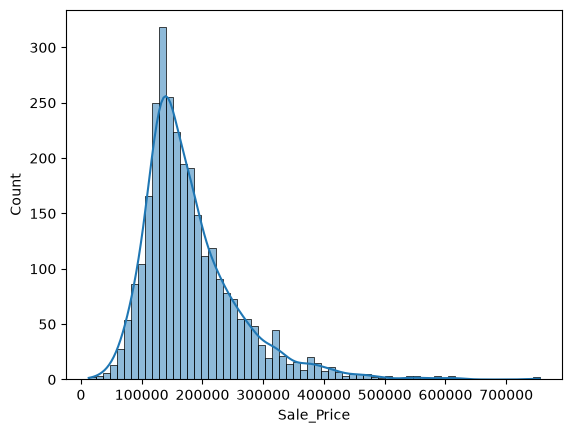

In [545]:
sns.histplot(df["Sale_Price"], kde=True)

# Target Variable Analysis: `Sale_Price`

The histogram below illustrates the distribution of the target variable, `Sale_Price`.

### 📊 Distribution Shape — Skewness

The distribution of `Sale_Price` is **positively skewed (right-skewed)**. Most observations are concentrated in the lower-to-middle price ranges, while a long tail extends toward higher property prices.

### 💰 Dominant Price Range

The majority of observations are concentrated approximately within the **$100,000–$250,000** range, indicating that this is the most common price range in the dataset.

### ⚠️ Extreme Values

The distribution contains several observations above approximately **$600,000–$700,000**. These values are far from the main concentration of the data and may represent **potential outliers or luxury properties**.

> Note: High-priced properties are not automatically considered outliers, as they may represent legitimate observations.

### 🤖 Modeling Implications

The strong right skewness of `Sale_Price` indicates that the target variable is not normally distributed. High-priced properties may also have a larger influence on error-based regression metrics.

At this stage, **no transformation is applied to the target variable**. The original `Sale_Price` values are retained for further analysis and modeling.

### 📝 Conclusion

> `Sale_Price` exhibits a strong positive skewness with a long right tail and several extreme high-price observations. These characteristics should be considered during model development, while the target variable is currently kept in its original form.


In [546]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage


In [547]:
print(f"Quantity duplicate: {df.duplicated().sum()}")
print(f"Quantity isnull: {df.isnull().sum().sum()}")

Quantity duplicate: 0
Quantity isnull: 0


In [548]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print(pd.Series(numerical_features))

Number of numerical features: 35
0           Lot_Frontage
1               Lot_Area
2             Year_Built
3         Year_Remod_Add
4           Mas_Vnr_Area
5           BsmtFin_SF_1
6           BsmtFin_SF_2
7            Bsmt_Unf_SF
8          Total_Bsmt_SF
9           First_Flr_SF
10         Second_Flr_SF
11       Low_Qual_Fin_SF
12           Gr_Liv_Area
13        Bsmt_Full_Bath
14        Bsmt_Half_Bath
15             Full_Bath
16             Half_Bath
17         Bedroom_AbvGr
18         Kitchen_AbvGr
19         TotRms_AbvGrd
20            Fireplaces
21           Garage_Cars
22           Garage_Area
23          Wood_Deck_SF
24         Open_Porch_SF
25        Enclosed_Porch
26    Three_season_porch
27          Screen_Porch
28             Pool_Area
29              Misc_Val
30               Mo_Sold
31             Year_Sold
32            Sale_Price
33             Longitude
34              Latitude
dtype: str


In [549]:
categorical_features = df.select_dtypes(
    include='category'
).columns.tolist()

print(f"Number of categorical features: {len(categorical_features)}")
print(pd.Series(categorical_features))

Number of categorical features: 46
0        MS_SubClass
1          MS_Zoning
2             Street
3              Alley
4          Lot_Shape
5       Land_Contour
6          Utilities
7         Lot_Config
8         Land_Slope
9       Neighborhood
10       Condition_1
11       Condition_2
12         Bldg_Type
13       House_Style
14      Overall_Qual
15      Overall_Cond
16        Roof_Style
17         Roof_Matl
18      Exterior_1st
19      Exterior_2nd
20      Mas_Vnr_Type
21        Exter_Qual
22        Exter_Cond
23        Foundation
24         Bsmt_Qual
25         Bsmt_Cond
26     Bsmt_Exposure
27    BsmtFin_Type_1
28    BsmtFin_Type_2
29           Heating
30        Heating_QC
31       Central_Air
32        Electrical
33      Kitchen_Qual
34        Functional
35      Fireplace_Qu
36       Garage_Type
37     Garage_Finish
38       Garage_Qual
39       Garage_Cond
40       Paved_Drive
41           Pool_QC
42             Fence
43      Misc_Feature
44         Sale_Type
45    Sale_Condition

In [550]:
feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(),
})

feature_summary

,Feature,Data_Type,Unique_Values
MS_SubClass,MS_SubClass,category,16
MS_Zoning,MS_Zoning,category,7
Lot_Frontage,Lot_Frontage,int64,129
Lot_Area,Lot_Area,int64,1960
Street,Street,category,2
...,...,...,...
Sale_Type,Sale_Type,category,10
Sale_Condition,Sale_Condition,category,6
Sale_Price,Sale_Price,int64,1032
Longitude,Longitude,float64,2776


In [551]:
feature_summary["Data_Type"].value_counts()

Data_Type
category    46
int64       33
float64      2
Name: count, dtype: int64

In [552]:
numerical_summery = df[numerical_features]
numerical_summery

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,...,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
0,141,31770,1960,1960,112,2,0,441,1080,1656,...,0,0,0,0,0,5,2010,215000,-93.619754,42.054035
1,80,11622,1961,1961,0,6,144,270,882,896,...,0,0,120,0,0,6,2010,105000,-93.619756,42.053014
2,81,14267,1958,1958,108,1,0,406,1329,1329,...,0,0,0,0,12500,6,2010,172000,-93.619387,42.052659
3,93,11160,1968,1968,0,1,0,1045,2110,2110,...,0,0,0,0,0,4,2010,244000,-93.617320,42.051245
4,74,13830,1997,1998,0,3,0,137,928,928,...,0,0,0,0,0,3,2010,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37,7937,1984,1984,0,3,0,184,1003,1003,...,0,0,0,0,0,3,2006,142500,-93.604776,41.988964
2926,0,8885,1983,1983,0,2,324,239,864,902,...,0,0,0,0,0,6,2006,131000,-93.602680,41.988314
2927,62,10441,1992,1992,0,3,0,575,912,970,...,0,0,0,0,700,7,2006,132000,-93.606847,41.986510
2928,77,10010,1974,1975,0,1,123,195,1389,1389,...,0,0,0,0,0,4,2006,170000,-93.600190,41.990921


In [553]:
categorical_summery = df[categorical_features]
categorical_summery

,MS_SubClass,MS_Zoning,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,...,Garage_Type,Garage_Finish,Garage_Qual,Garage_Cond,Paved_Drive,Pool_QC,Fence,Misc_Feature,Sale_Type,Sale_Condition
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Partial_Pavement,No_Pool,No_Fence,None,WD,Normal
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,No_Fence,Gar2,WD,Normal
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal
4,Two_Story_1946_and_Newer,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,...,Attchd,Fin,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,...,Detchd,Unf,Typical,Typical,Paved,No_Pool,Good_Privacy,None,WD,Normal
2926,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,Low,AllPub,Inside,Mod,Mitchell,...,Attchd,Unf,Typical,Typical,Paved,No_Pool,Minimum_Privacy,None,WD,Normal
2927,Split_Foyer,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,Mitchell,...,No_Garage,No_Garage,No_Garage,No_Garage,Paved,No_Pool,Minimum_Privacy,Shed,WD,Normal
2928,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Mod,Mitchell,...,Attchd,RFn,Typical,Typical,Paved,No_Pool,No_Fence,None,WD,Normal


## Feature Visualization

To better understand the most important features, selected numerical and categorical variables are visualized and analyzed based on their distributions and relationships with `Sale_Price`.

### Numerical Features

The following numerical features are visualized:

* `Gr_Liv_Area`
* `Year_Built`
* `Year_Remod_Add`
* `Total_Bsmt_SF`
* `First_Flr_SF`
* `Second_Flr_SF`
* `Garage_Cars`
* `Garage_Area`
* `TotRms_AbvGrd`
* `Fireplaces`
* `Lot_Area`
* `Mas_Vnr_Area`

The plots are used to examine their **distributions, potential skewness, and relationships with `Sale_Price`**.

### Categorical Features

The following categorical features are visualized:

* `Overall_Qual`
* `Neighborhood`
* `Kitchen_Qual`
* `Bsmt_Qual`
* `Garage_Finish`
* `Garage_Type`
* `Exter_Qual`
* `Heating_QC`

The plots are used to examine their **category distributions and differences in `Sale_Price` across categories**.

### Analysis Goal

The goal is to identify important patterns and relationships among the selected features before proceeding to **outlier analysis**.


## 📊 Categirical

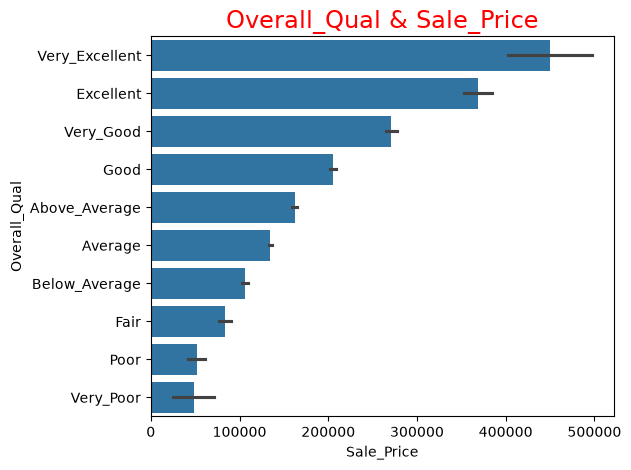

In [554]:
fig, ax = plt.subplots()

order_list = df.groupby('Overall_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    y='Overall_Qual',
    x='Sale_Price',
    order=order_list
)

ax.set_title('Overall_Qual & Sale_Price', size=17, color='red')
fig.tight_layout()
plt.show()


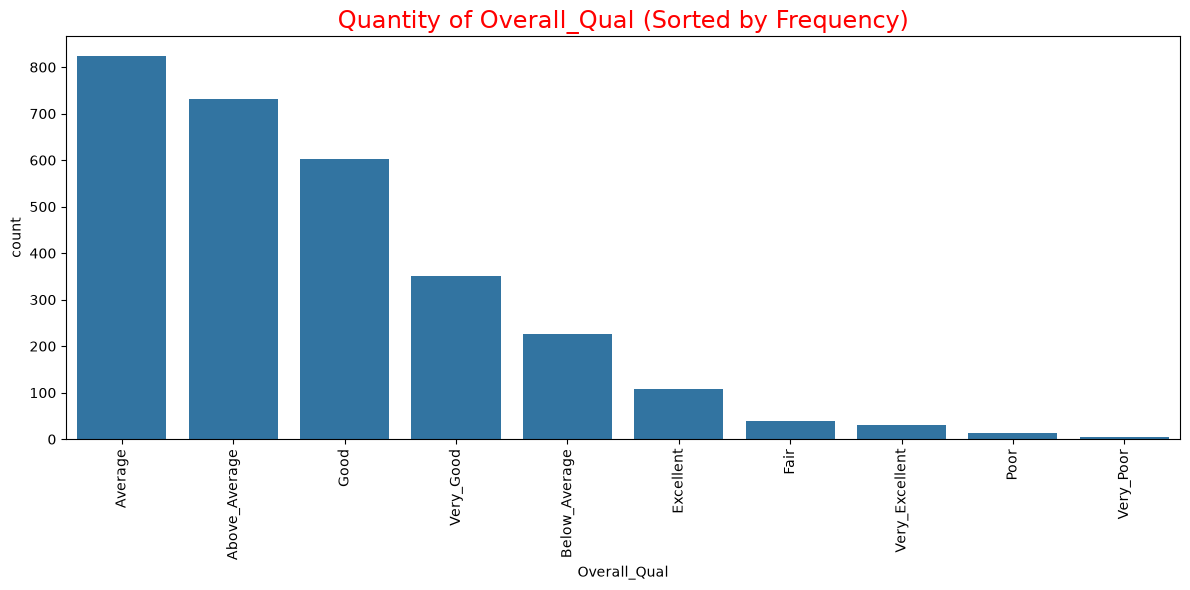

In [555]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Overall_Qual'].value_counts().index
sns.countplot(
    data=df,
    x='Overall_Qual',
    order=my_order
)

ax.set_title('Quantity of Overall_Qual (Sorted by Frequency)', size=17, color='red')
plt.xticks(rotation=90)
fig.tight_layout()
plt.show()


### Overall Quality Analysis

The `Overall_Qual` feature represents the overall quality of the houses, ranging from **Very Excellent** to **Very Poor**.

The count plot shows that the dataset is not evenly distributed across the quality categories, with **Average, Above Average, and Good** representing the most common categories.

The bar plot shows a clear difference in the average `Sale_Price` across quality levels. In general, houses with higher overall quality tend to have higher average sale prices, while lower-quality houses tend to have lower average sale prices.

Overall, `Overall_Qual` shows a strong relationship with `Sale_Price` and appears to be one of the most informative categorical features for the prediction task.


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'Northridge'),
  Text(1, 0, 'Stone_Brook'),
  Text(2, 0, 'Northridge_Heights'),
  Text(3, 0, 'Green_Hills'),
  Text(4, 0, 'Veenker'),
  Text(5, 0, 'Timberland'),
  Text(6, 0, 'Somerset'),
  Text(7, 0, 'Clear_Creek'),
  Text(8, 0, 'Crawford'),
  Text(9, 0, 'College_Creek'),
  Text(10, 0, 'Bloomington_Heights'),
  Text(11, 0, 'Greens'),
  Text(12, 0, 'Gilbert'),
  Text(13, 0, 'Northwest_Ames'),
  Text(14, 0, 'Sawyer_West'),
  Text(15, 0, 'Mitchell'),
  Text(16, 0, 'North_Ames'),
  Text(17, 0, 'Blueste'),
  Text(18, 0, 'Northpark_Villa'),
  Text(19, 0, 'Landmark'),
  Text(20, 0, 'Sawyer'),
  Text(21, 0, 'South_and_West_of_Iowa_State_University'),
  Text(22, 0, 'Edwards'),
  Text(23, 0, 'Brookside'),
  Text(24, 0, 'Old_Town'),
  Text(25, 0, 'Briardale'),
  Text(26, 0, 'Iowa_DOT_and_Rail_Road'),
  Text(27, 0, 'Meadow_Vill

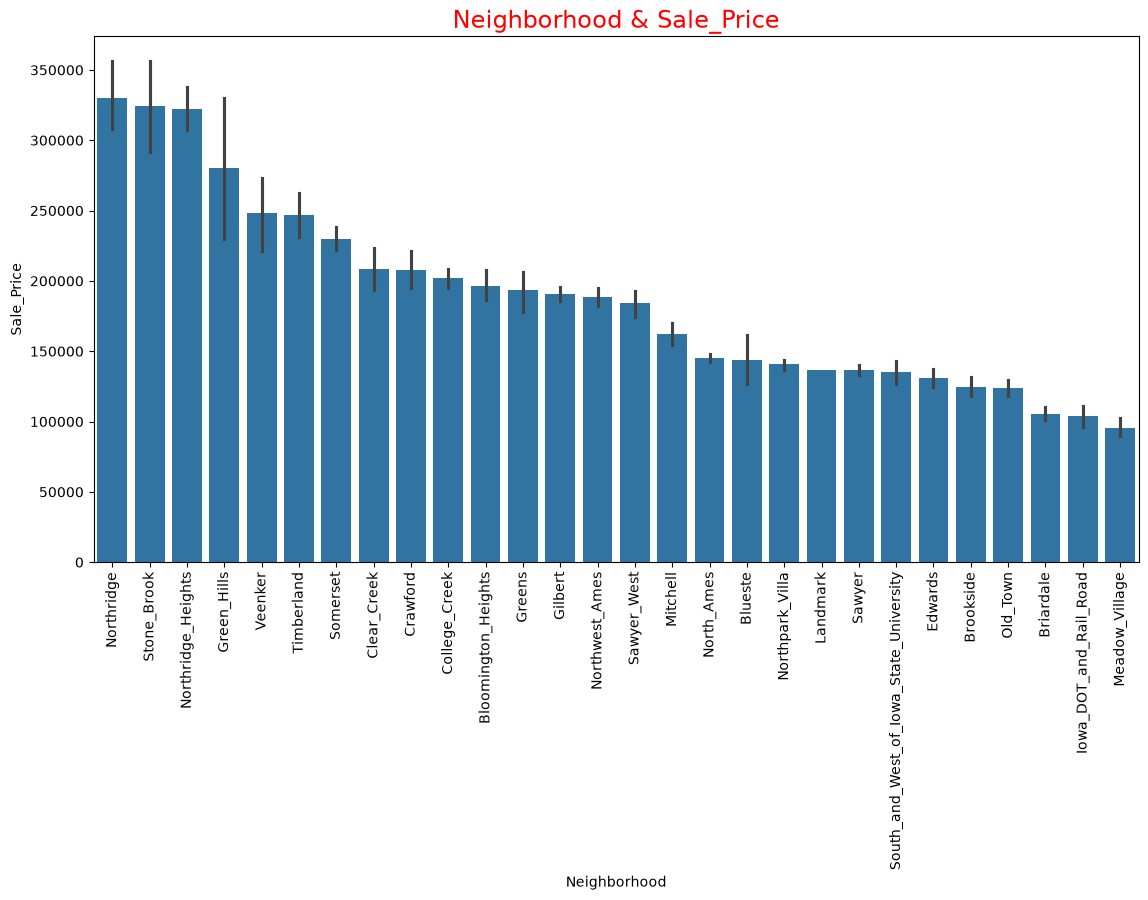

In [556]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Neighborhood')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Neighborhood',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Neighborhood & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'North_Ames'),
  Text(1, 0, 'College_Creek'),
  Text(2, 0, 'Old_Town'),
  Text(3, 0, 'Edwards'),
  Text(4, 0, 'Somerset'),
  Text(5, 0, 'Northridge_Heights'),
  Text(6, 0, 'Gilbert'),
  Text(7, 0, 'Sawyer'),
  Text(8, 0, 'Northwest_Ames'),
  Text(9, 0, 'Sawyer_West'),
  Text(10, 0, 'Mitchell'),
  Text(11, 0, 'Brookside'),
  Text(12, 0, 'Crawford'),
  Text(13, 0, 'Iowa_DOT_and_Rail_Road'),
  Text(14, 0, 'Timberland'),
  Text(15, 0, 'Northridge'),
  Text(16, 0, 'Stone_Brook'),
  Text(17, 0, 'South_and_West_of_Iowa_State_University'),
  Text(18, 0, 'Clear_Creek'),
  Text(19, 0, 'Meadow_Village'),
  Text(20, 0, 'Briardale'),
  Text(21, 0, 'Bloomington_Heights'),
  Text(22, 0, 'Veenker'),
  Text(23, 0, 'Northpark_Villa'),
  Text(24, 0, 'Blueste'),
  Text(25, 0, 'Greens'),
  Text(26, 0, 'Green_Hills'),
  Text(27, 0, 'Landm

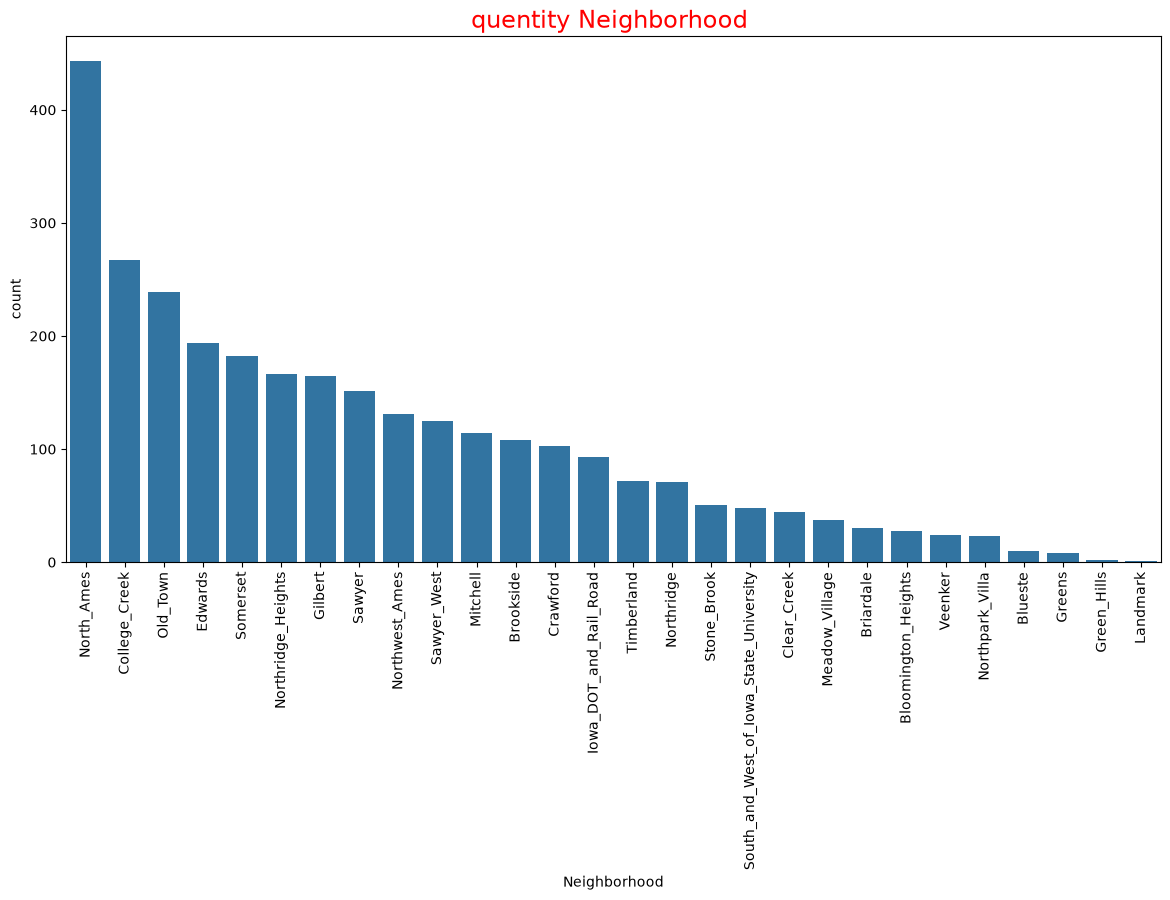

In [557]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Neighborhood'].value_counts().index

sns.countplot(
    data=df,
    x='Neighborhood',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Neighborhood ', size=17, color='red')
plt.xticks(rotation=90)


### Neighborhood Analysis

The `Neighborhood` feature shows substantial differences in average `Sale_Price` across different neighborhoods.

The bar plot ranks the neighborhoods according to their average sale price. **Northridge, Stone_Brook, Northridge_Heights, and Green_Hills** are among the neighborhoods with the highest average sale prices, while **Meadow_Village, Iowa_DOT_and_Rail_Road, Briardale, and Old_Town** are among the lower-priced neighborhoods.

The count plot also shows that the number of houses varies considerably across neighborhoods, indicating an uneven distribution of observations.

Overall, `Neighborhood` appears to be an important categorical feature because the average sale price differs substantially between neighborhoods.


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Poor'),
  Text(4, 0, 'Fair')])

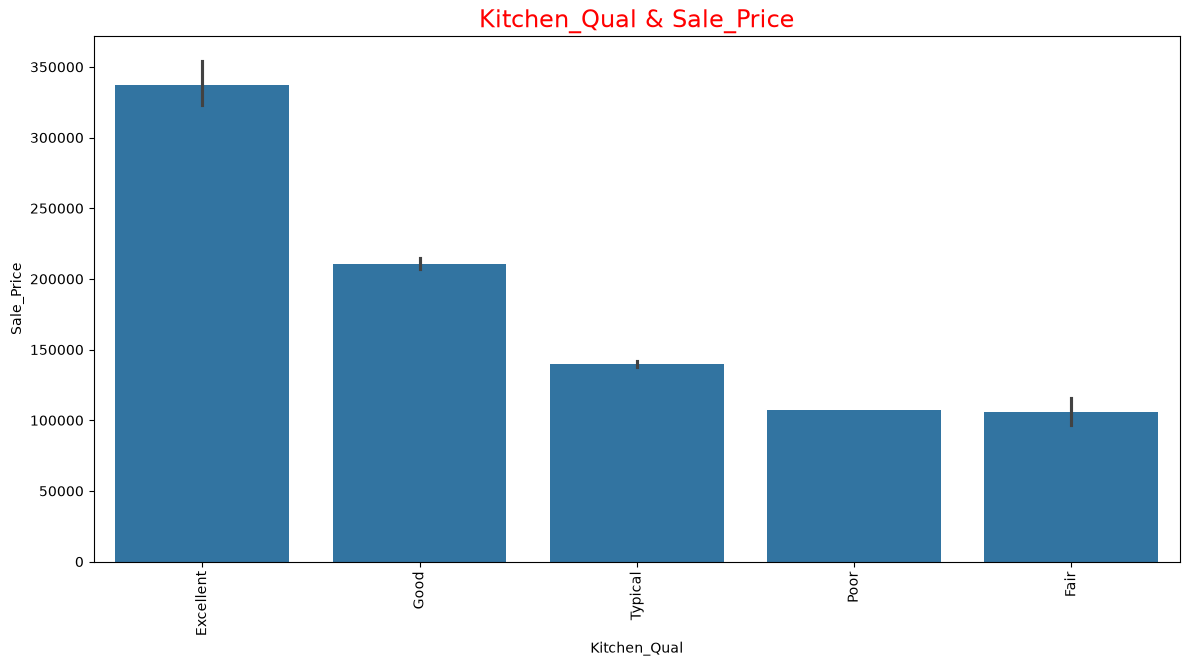

In [558]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Kitchen_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Kitchen_Qual',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Kitchen_Qual & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Typical'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Excellent'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'Poor')])

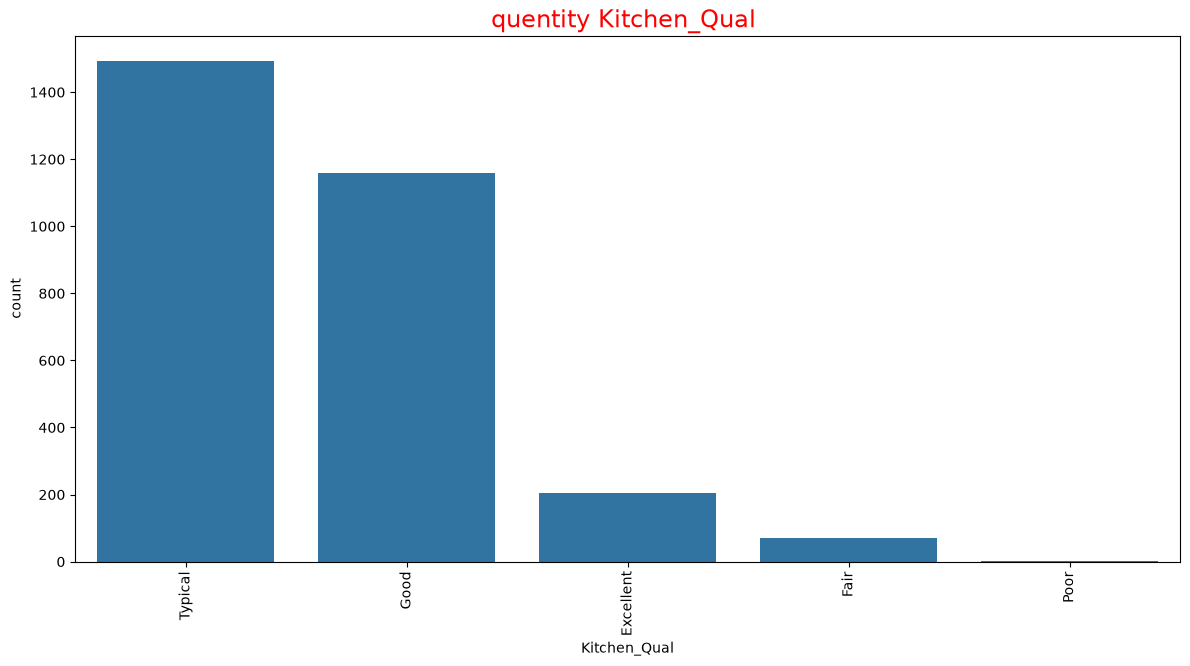

In [559]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Kitchen_Qual'].value_counts().index

sns.countplot(
    data=df,
    x='Kitchen_Qual',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Kitchen_Qual ', size=17, color='red')
plt.xticks(rotation=90)


### Kitchen Quality Analysis

The `Kitchen_Qual` feature represents the quality of the kitchen, ranging from **Excellent** to **Poor**.

The count plot shows that most houses are concentrated in the **Typical** and **Good** categories, while the other categories occur less frequently.

The bar plot shows differences in the average `Sale_Price` across kitchen quality levels. In general, higher kitchen quality is associated with higher average sale prices, while lower-quality kitchens tend to have lower average sale prices.

Overall, `Kitchen_Qual` appears to be an informative categorical feature for predicting `Sale_Price`.


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'No_Basement'),
  Text(5, 0, 'Poor')])

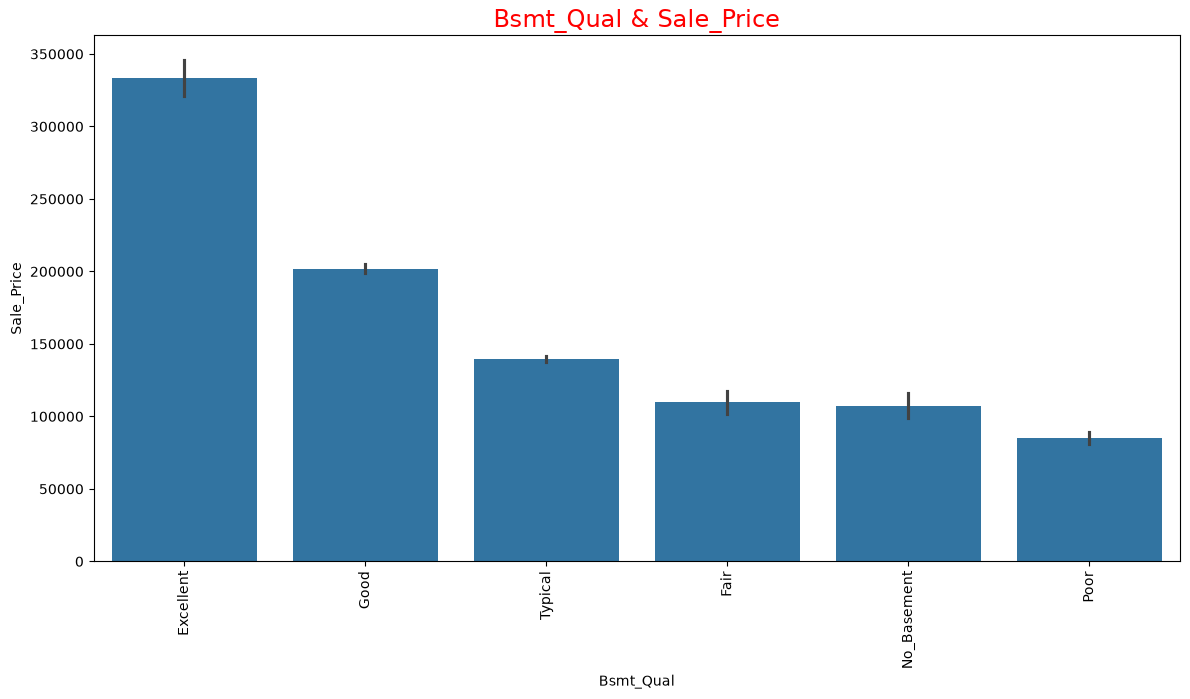

In [560]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Bsmt_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Bsmt_Qual',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Bsmt_Qual & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Typical'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Excellent'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'No_Basement'),
  Text(5, 0, 'Poor')])

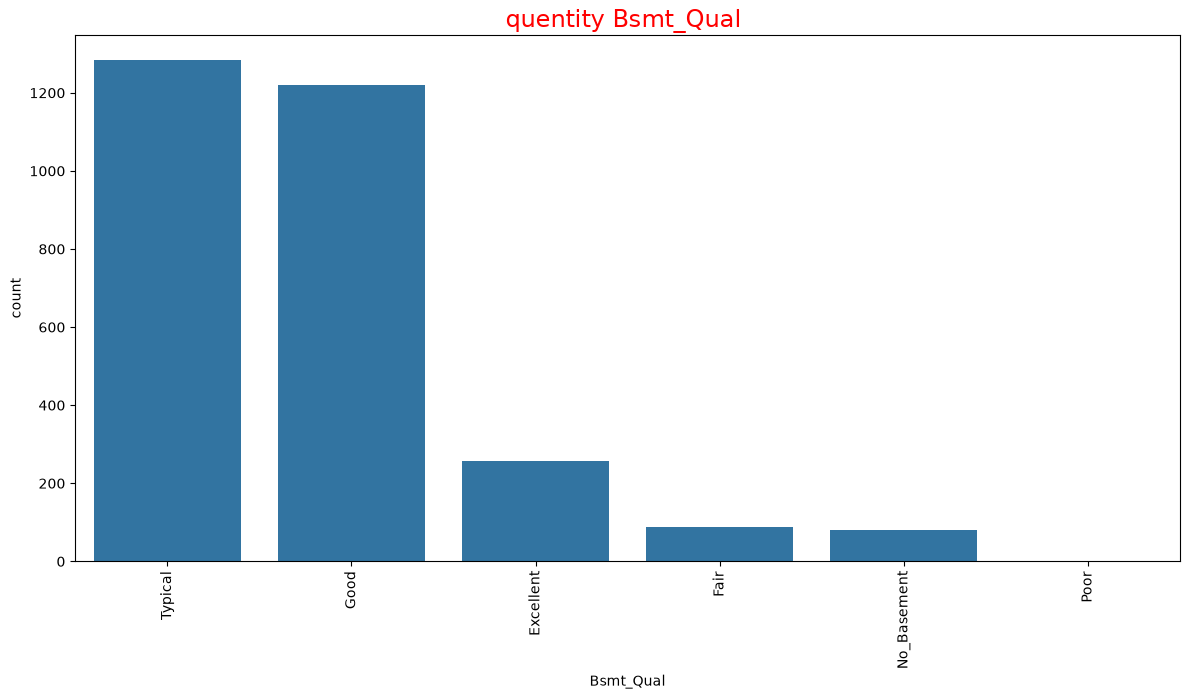

In [561]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Bsmt_Qual'].value_counts().index

sns.countplot(
    data=df,
    x='Bsmt_Qual',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Bsmt_Qual ', size=17, color='red')
plt.xticks(rotation=90)


### Basement Quality Analysis

The `Bsmt_Qual` feature represents the quality of the basement, ranging from **Excellent** to **Poor**, with a separate category for houses without a basement.

The count plot shows that the observations are unevenly distributed across the basement quality categories, with some categories occurring much more frequently than others.

The bar plot shows noticeable differences in average `Sale_Price` between the basement quality categories. Overall, higher basement quality is associated with higher average sale prices, while lower-quality basements and houses without a basement tend to have lower average sale prices.

These differences indicate that `Bsmt_Qual` provides useful information for predicting `Sale_Price`.


([0, 1, 2, 3],
 [Text(0, 0, 'Fin'),
  Text(1, 0, 'RFn'),
  Text(2, 0, 'Unf'),
  Text(3, 0, 'No_Garage')])

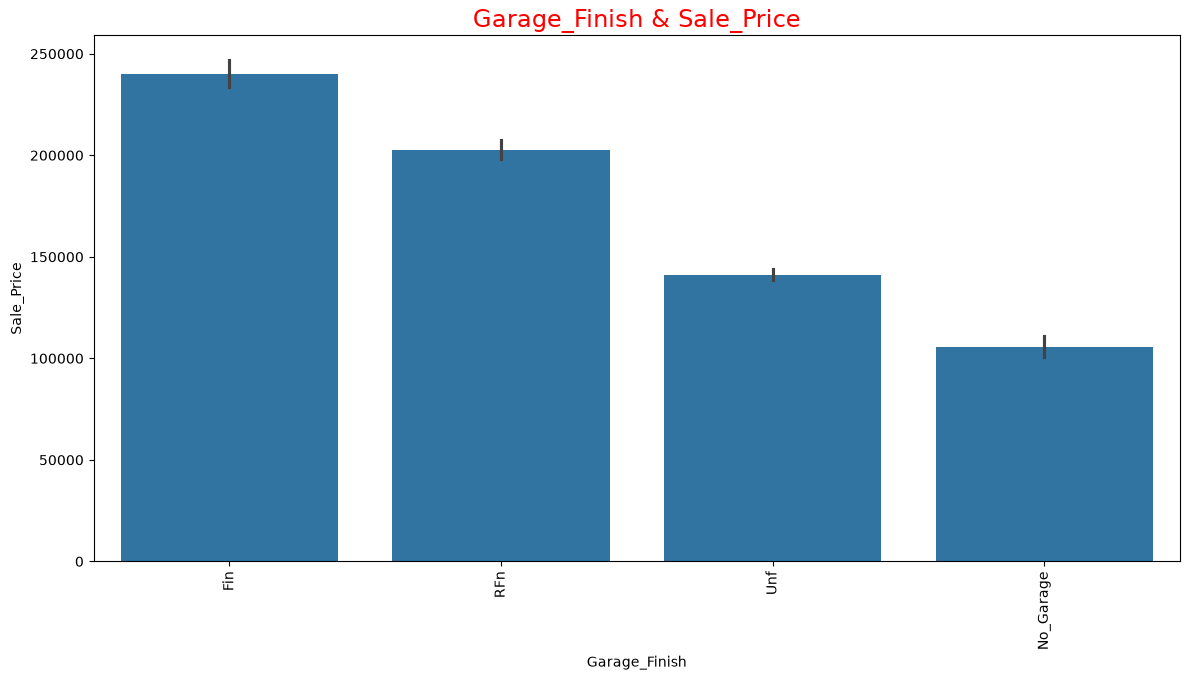

In [562]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Garage_Finish')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Garage_Finish',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Garage_Finish & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3],
 [Text(0, 0, 'Unf'),
  Text(1, 0, 'RFn'),
  Text(2, 0, 'Fin'),
  Text(3, 0, 'No_Garage')])

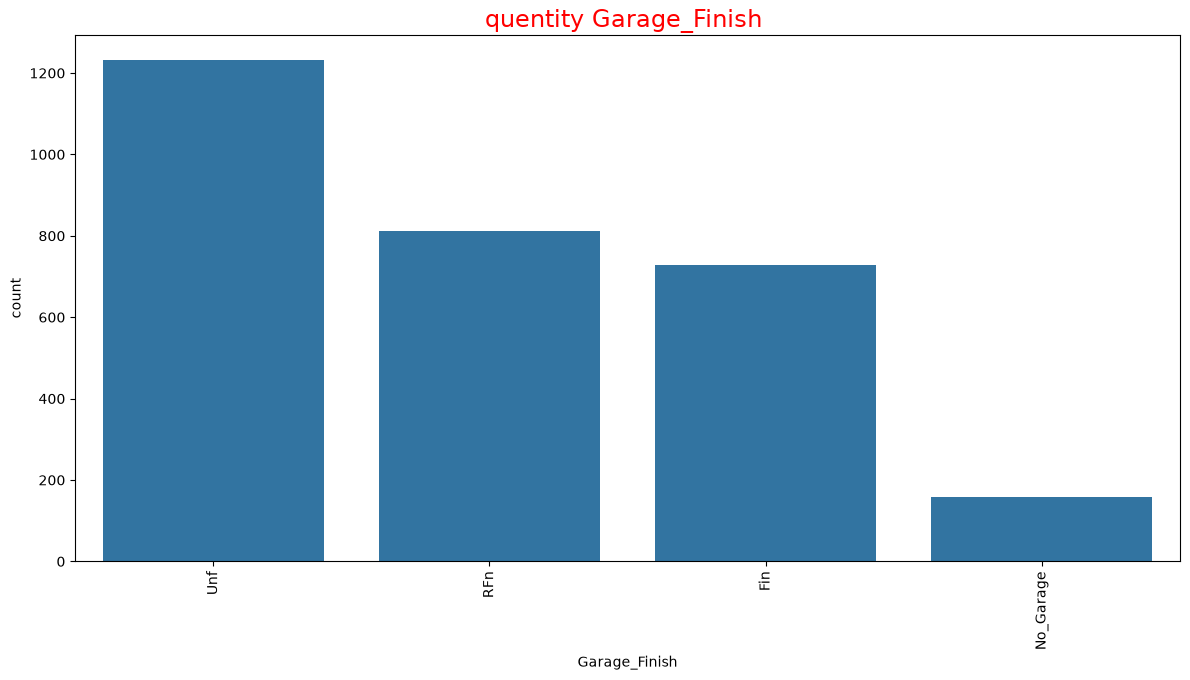

In [563]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Garage_Finish'].value_counts().index

sns.countplot(
    data=df,
    x='Garage_Finish',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Garage_Finish ', size=17, color='red')
plt.xticks(rotation=90)


### Garage Finish Analysis

The `Garage_Finish` feature represents the level of interior finish of the garage, including **Finished**, **Rough Finished**, and **Unfinished**, along with a category for houses without a garage.

The count plot shows that the garage finish categories are not evenly distributed, with some categories occurring more frequently than others.

The bar plot shows differences in average `Sale_Price` between the garage finish categories. Houses with more finished garages generally have higher average sale prices, while houses with unfinished or no garages tend to have lower average sale prices.

Overall, `Garage_Finish` appears to provide useful information for predicting `Sale_Price`.


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'BuiltIn'),
  Text(1, 0, 'Attchd'),
  Text(2, 0, 'More_Than_Two_Types'),
  Text(3, 0, 'Basment'),
  Text(4, 0, 'Detchd'),
  Text(5, 0, 'CarPort'),
  Text(6, 0, 'No_Garage')])

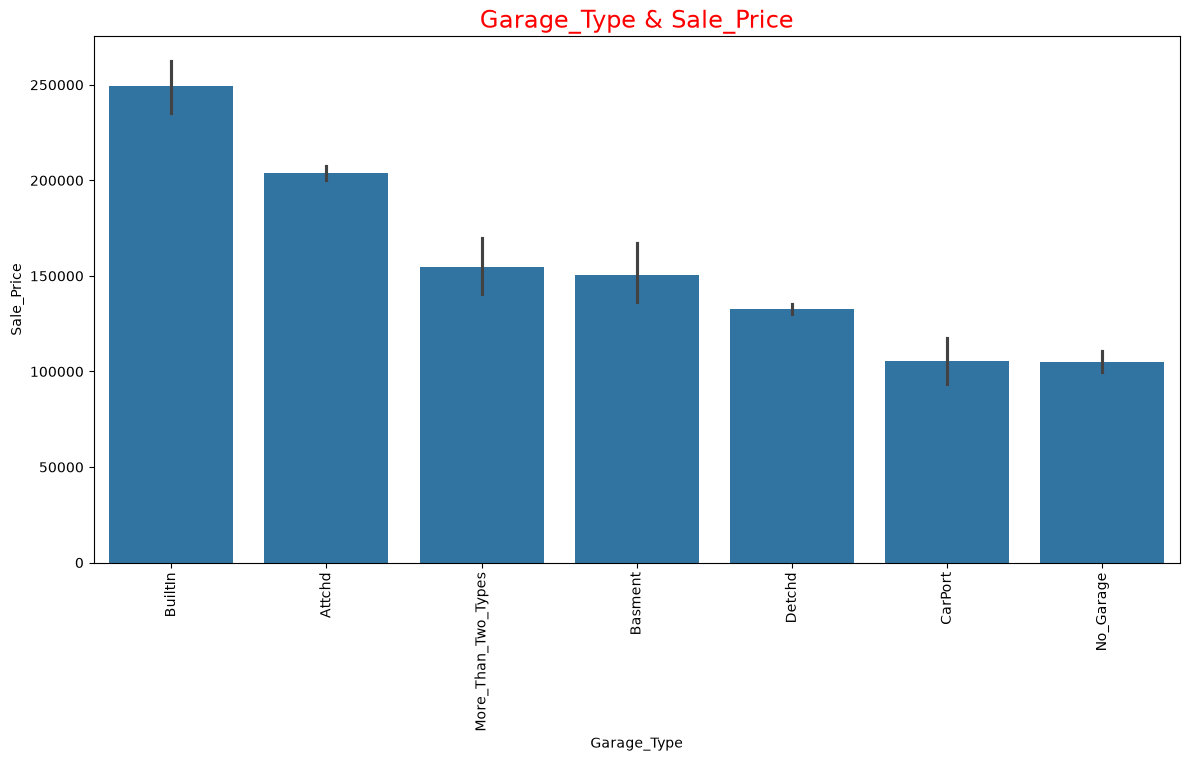

In [564]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Garage_Type')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Garage_Type',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Garage_Type & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Attchd'),
  Text(1, 0, 'Detchd'),
  Text(2, 0, 'BuiltIn'),
  Text(3, 0, 'No_Garage'),
  Text(4, 0, 'Basment'),
  Text(5, 0, 'More_Than_Two_Types'),
  Text(6, 0, 'CarPort')])

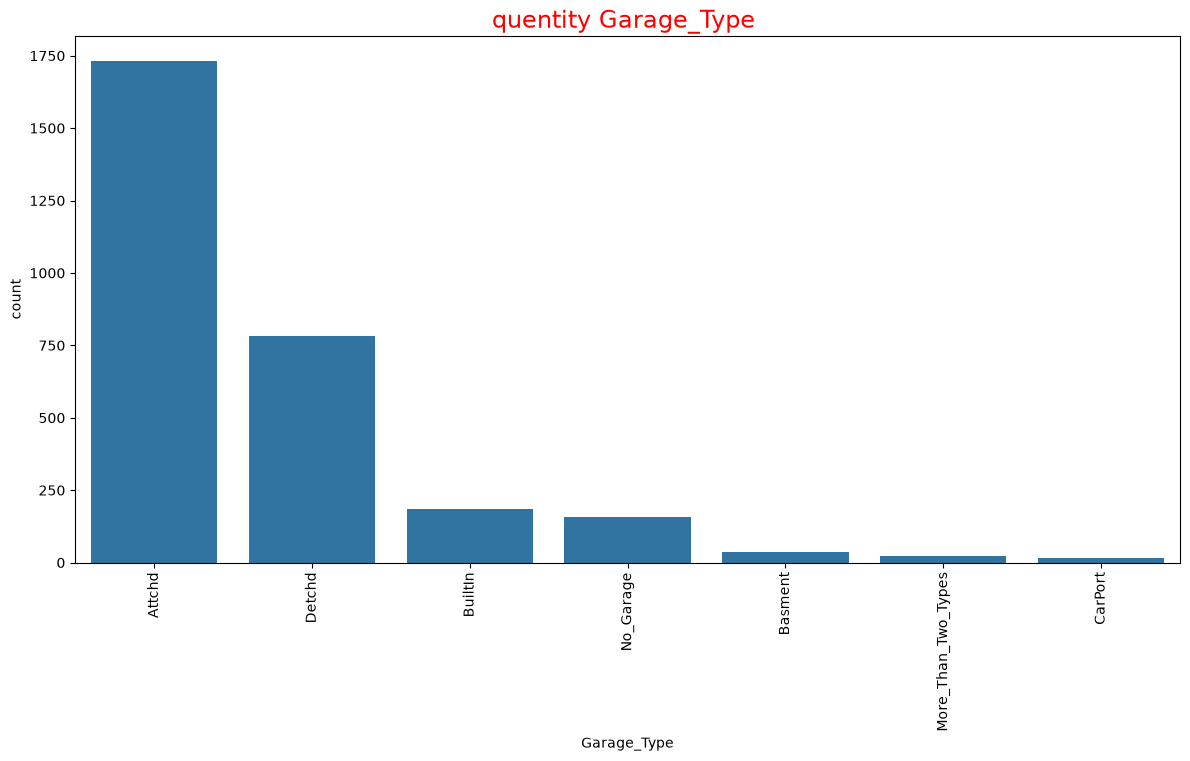

In [565]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Garage_Type'].value_counts().index

sns.countplot(
    data=df,
    x='Garage_Type',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Garage_Type ', size=17, color='red')
plt.xticks(rotation=90)


### Garage Type Analysis

The `Garage_Type` feature represents the type or location of the garage, including different garage configurations as well as houses without a garage.

The count plot shows that some garage types are much more common than others, resulting in an uneven distribution across categories.

The bar plot shows noticeable differences in average `Sale_Price` between garage types. This indicates that the type and presence of a garage are associated with differences in house sale prices.

Overall, `Garage_Type` appears to be a useful categorical feature for predicting `Sale_Price`.


([0, 1, 2, 3],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Fair')])

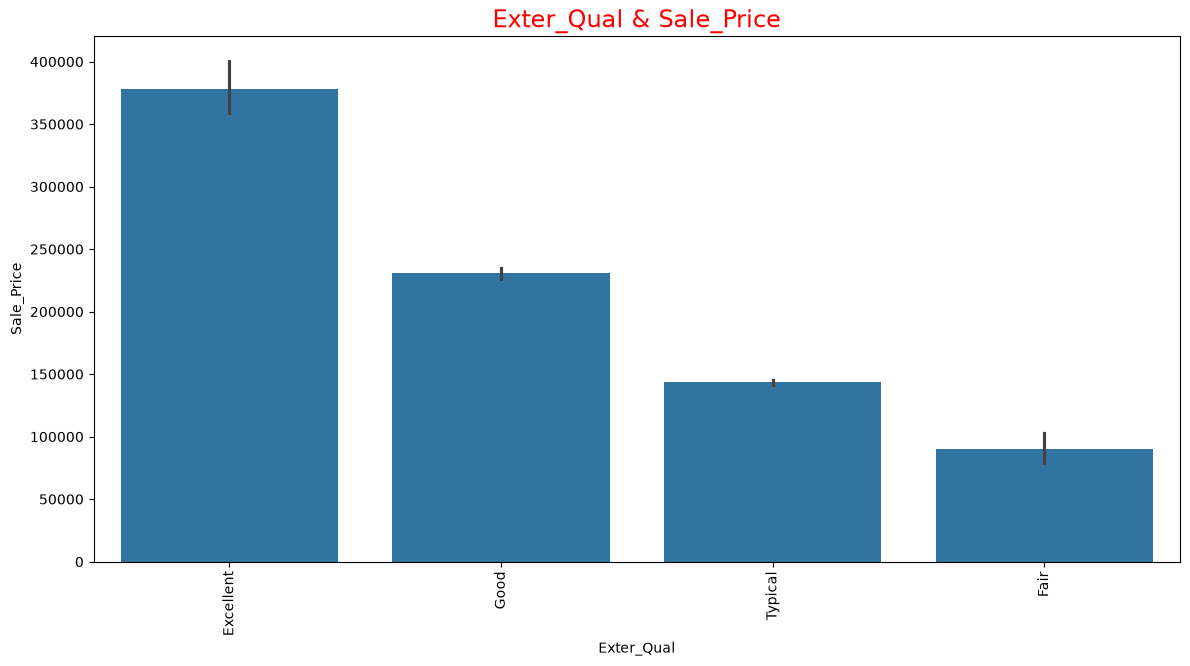

In [566]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Exter_Qual')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Exter_Qual',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Exter_Qual & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3],
 [Text(0, 0, 'Typical'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Excellent'),
  Text(3, 0, 'Fair')])

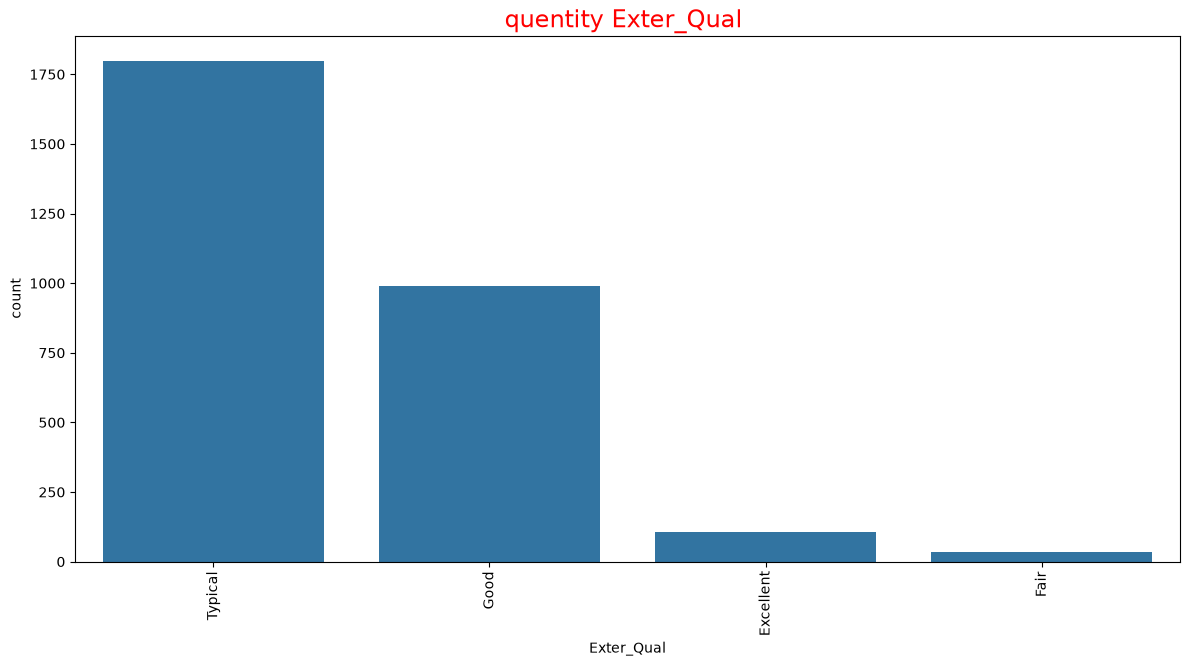

In [567]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Exter_Qual'].value_counts().index

sns.countplot(
    data=df,
    x='Exter_Qual',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Exter_Qual ', size=17, color='red')
plt.xticks(rotation=90)


### Exterior Quality Analysis

The `Exter_Qual` feature represents the quality of the house's exterior materials, ranging from **Excellent** to **Poor**.

The count plot shows that the observations are concentrated in some quality categories more than others, indicating an uneven distribution.

The bar plot shows clear differences in average `Sale_Price` across exterior quality levels. In general, houses with higher exterior quality tend to have higher average sale prices, while lower-quality houses tend to have lower average sale prices.

Overall, `Exter_Qual` appears to be an informative categorical feature for predicting `Sale_Price`.


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Good'),
  Text(2, 0, 'Typical'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'Poor')])

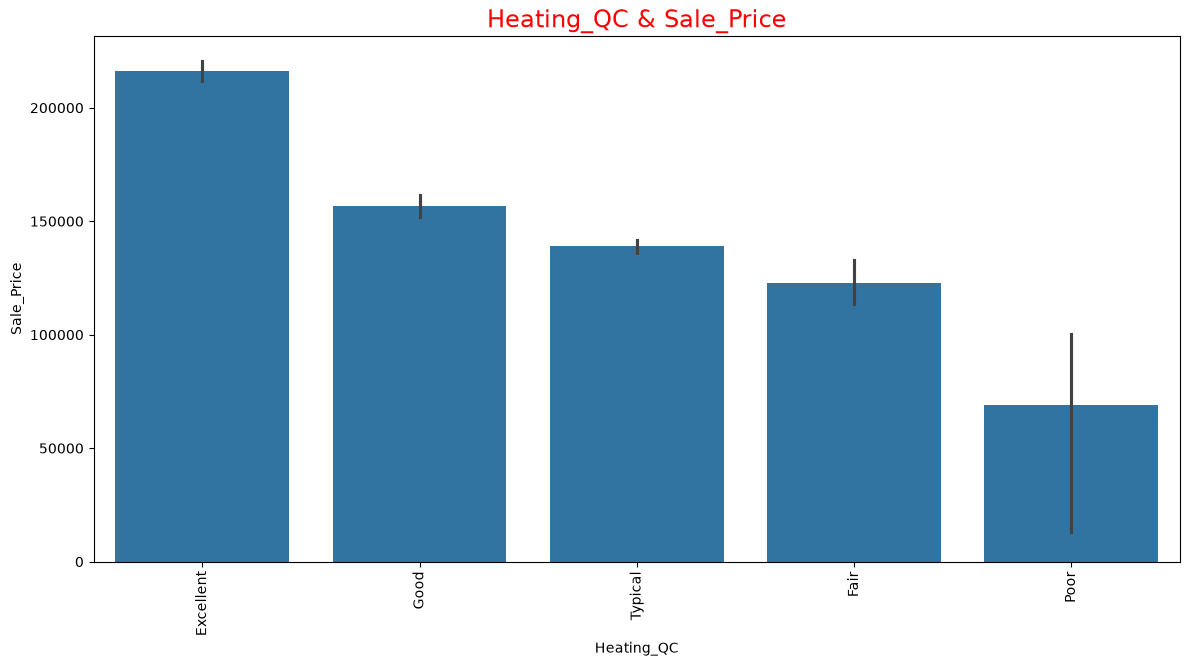

In [568]:
fig, ax = plt.subplots(figsize=(12, 6))

order_list = df.groupby('Heating_QC')['Sale_Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Heating_QC',
    y='Sale_Price',
    order=order_list
)
fig.tight_layout()

ax.set_title('Heating_QC & Sale_Price', size=17, color='red')
plt.xticks(rotation=90)


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Excellent'),
  Text(1, 0, 'Typical'),
  Text(2, 0, 'Good'),
  Text(3, 0, 'Fair'),
  Text(4, 0, 'Poor')])

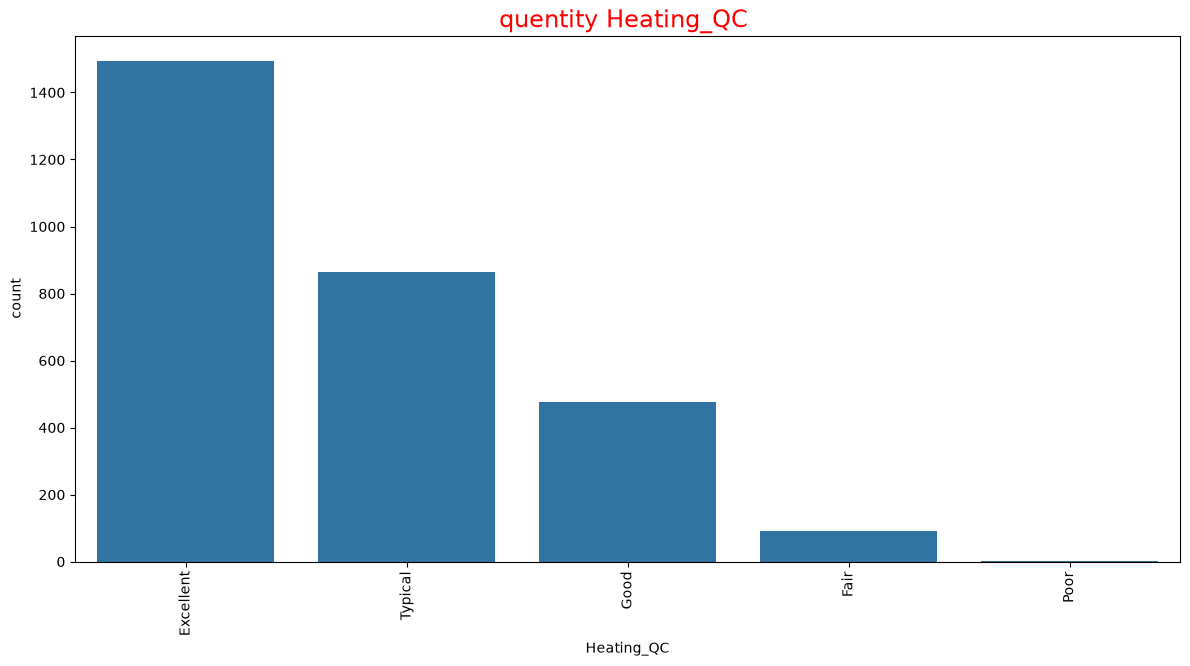

In [569]:
fig, ax = plt.subplots(figsize=(12, 6))

my_order = df['Heating_QC'].value_counts().index

sns.countplot(
    data=df,
    x='Heating_QC',
    order=my_order
)
fig.tight_layout()

ax.set_title('quentity Heating_QC ', size=17, color='red')
plt.xticks(rotation=90)


### Heating Quality Analysis

The `Heating_QC` feature represents the quality and condition of the house's heating system, ranging from **Excellent** to **Poor**.

The count plot shows that the observations are not evenly distributed across the heating quality categories, with some categories occurring more frequently than others.

The bar plot shows differences in average `Sale_Price` across heating quality levels. In general, houses with better heating quality tend to have higher average sale prices, while lower heating quality is associated with lower average sale prices.

Overall, `Heating_QC` provides useful information about differences in `Sale_Price` and can be considered an informative categorical feature for the prediction task.


## Categorical Features Analysis

The categorical feature analysis was performed using two complementary perspectives:

* **Count plots** were used to examine the distribution of observations across different categories.
* **Bar plots** were used to compare the average `Sale_Price` across categories.

The analysis shows that the categorical features are generally **not evenly distributed**. Some categories contain considerably more observations than others, which is particularly noticeable for features such as `Neighborhood`, `Kitchen_Qual`, `Garage_Type`, and `Heating_QC`.

The comparison of average `Sale_Price` across categories also reveals **substantial differences in house prices between several categorical groups**. Features related to house quality, such as `Overall_Qual`, `Kitchen_Qual`, `Bsmt_Qual`, and `Exter_Qual`, show noticeable differences in average sale prices across their quality levels. Similarly, `Neighborhood`, `Garage_Finish`, `Garage_Type`, and `Heating_QC` show variations in average `Sale_Price` between their respective categories.

Among the analyzed features, `Overall_Qual` shows one of the clearest relationships with `Sale_Price`, while `Neighborhood` also shows considerable variation in average house prices across different locations.

Overall, the categorical analysis indicates that these features contain **valuable information for explaining differences in house sale prices**. Therefore, categorical variables should be carefully considered during the preprocessing and modeling stages rather than being treated as insignificant features.

These findings provide a basis for the next stage of the analysis, where **potential outliers and unusual observations** will be investigated before building the regression models.


## 📊 Numerical

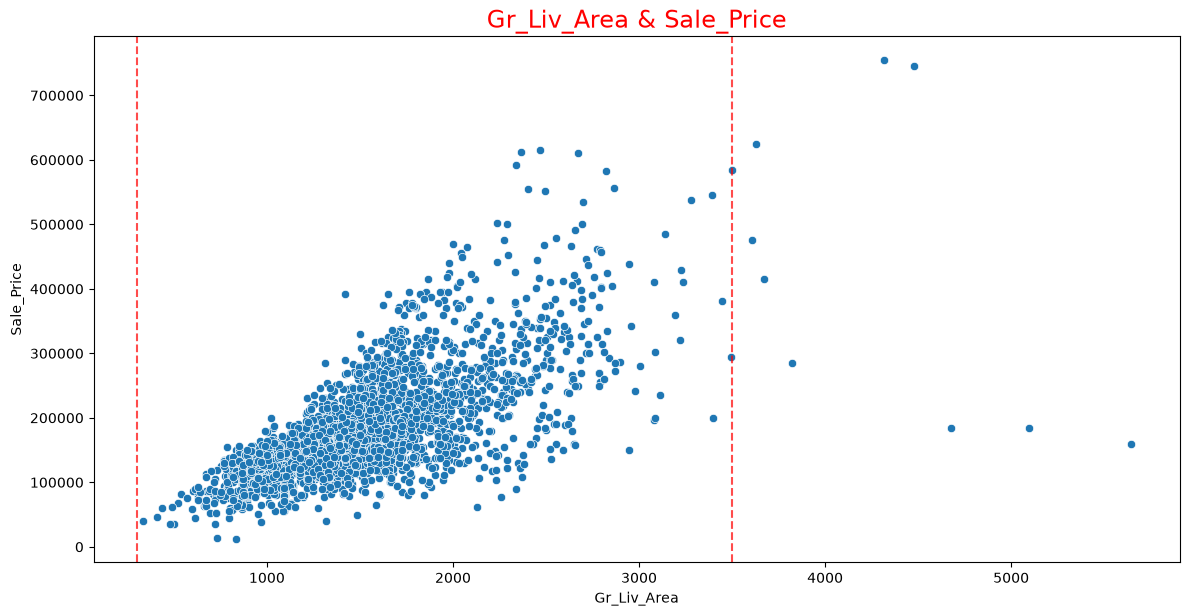

In [570]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Gr_Liv_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Gr_Liv_Area & Sale_Price', size=17, color='red')

ax.axvline(x=300, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=3500, color='red', linestyle='--', alpha=0.7)

### Above Ground Living Area Analysis

The scatter plot shows a clear positive relationship between `Gr_Liv_Area` and `Sale_Price`. In general, houses with larger above-ground living areas tend to have higher sale prices.

Most observations are concentrated within a relatively common range of living areas, while a smaller number of houses have extremely small or very large living areas.

The plot also highlights observations outside the main range, particularly below approximately **300 square feet** and above approximately **3,500 square feet**. These observations should be examined further during the outlier analysis.

Overall, `Gr_Liv_Area` appears to be one of the most informative numerical features for predicting `Sale_Price`.


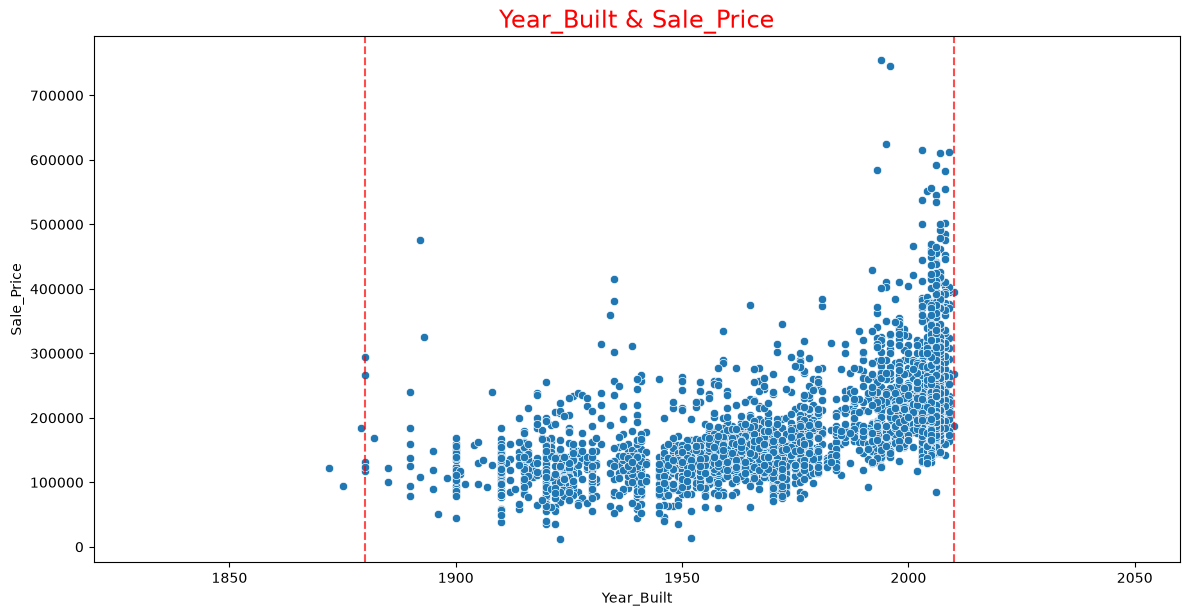

In [571]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Year_Built', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Year_Built & Sale_Price', size=17, color='red')
ax.set_xlim(1820, 2060)

ax.axvline(x=1880, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=2010, color='red', linestyle='--', alpha=0.7)

### Year Built Analysis

The scatter plot shows a general positive relationship between `Year_Built` and `Sale_Price`. Houses built more recently tend to have higher sale prices compared with many older houses.

The observations are distributed across a wide range of construction years, although most houses are concentrated within the more recent portion of the dataset.

The plot also identifies observations near the lower and upper boundaries of the observed construction years. These extreme values should be considered when investigating potential outliers and unusual observations.

Overall, `Year_Built` provides useful information about differences in `Sale_Price`, although the relationship is not perfectly linear.


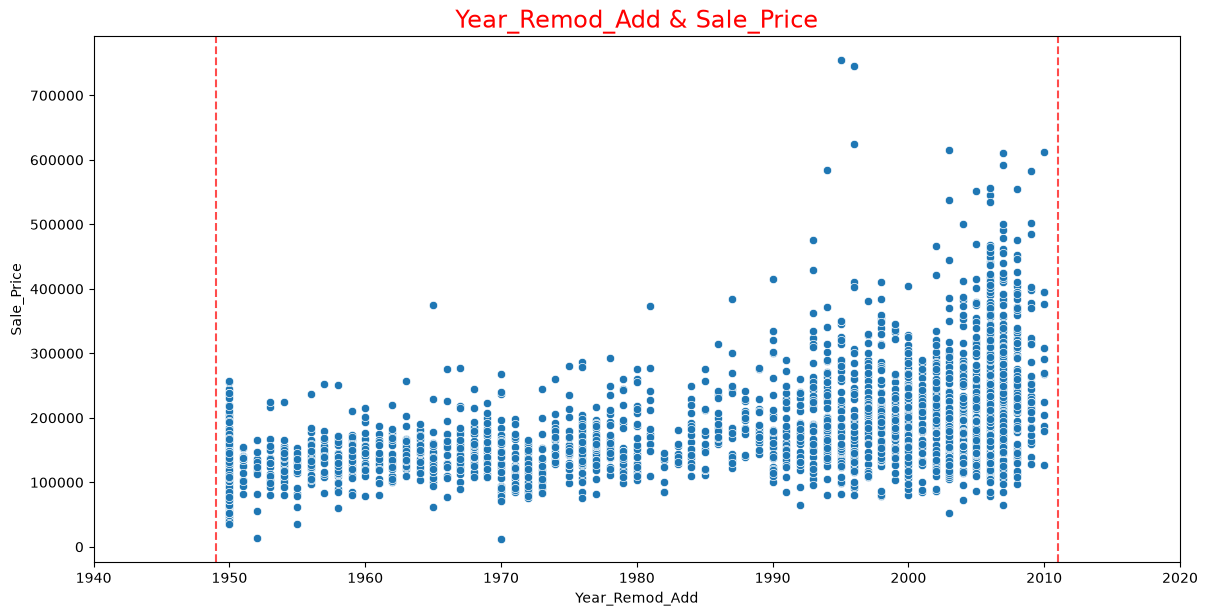

In [572]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Year_Remod_Add', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Year_Remod_Add & Sale_Price', size=17, color='red')
ax.set_xlim(1940, 2020)

ax.axvline(x=1949, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=2011, color='red', linestyle='--', alpha=0.7)

### Remodeling Year Analysis

The scatter plot shows a positive relationship between `Year_Remod_Add` and `Sale_Price`. Houses that were remodeled more recently generally tend to have higher sale prices.

The observations cover a broad range of remodeling years, with a greater concentration in the more recent years.

The relationship is not perfectly linear, indicating that the remodeling year alone does not fully explain differences in sale prices.

Overall, `Year_Remod_Add` appears to be a useful numerical feature, providing information about the recency of a property's remodeling.


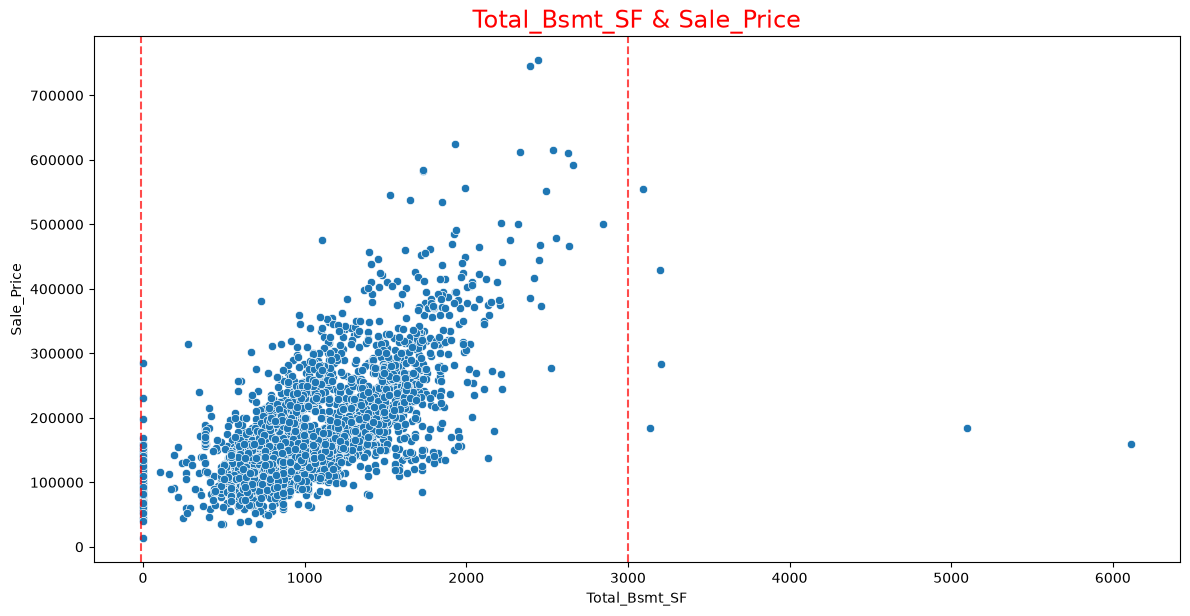

In [573]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Total_Bsmt_SF', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Total_Bsmt_SF & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=3000, color='red', linestyle='--', alpha=0.7)

### Total Basement Area Analysis

The scatter plot shows a generally positive relationship between `Total_Bsmt_SF` and `Sale_Price`. Houses with larger total basement areas tend to have higher sale prices.

A considerable number of observations are concentrated within the lower and middle ranges of basement area, while larger basement areas are less common.

The plot also highlights observations beyond the main range, particularly values approaching or exceeding **3,000 square feet**, which may require further investigation during outlier analysis.

Overall, `Total_Bsmt_SF` appears to provide useful information for predicting `Sale_Price`.


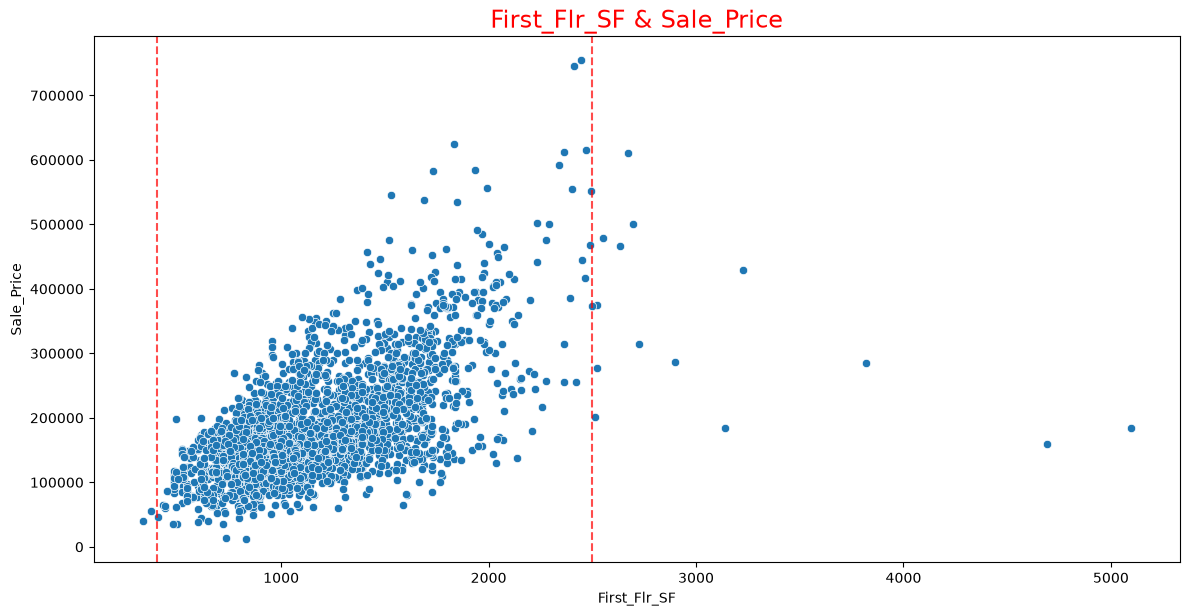

In [574]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='First_Flr_SF', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('First_Flr_SF & Sale_Price', size=17, color='red')

ax.axvline(x=400, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=2500, color='red', linestyle='--', alpha=0.7)

### First Floor Area Analysis

The scatter plot shows a positive relationship between `First_Flr_SF` and `Sale_Price`. Houses with larger first-floor areas generally tend to have higher sale prices.

Most observations are concentrated within the central range of first-floor area, while very small and very large values occur less frequently.

The values below approximately **400 square feet** and above approximately **2,500 square feet** represent observations outside the main range and should be examined further as potential unusual observations.

Overall, `First_Flr_SF` appears to be an informative numerical feature for predicting `Sale_Price`.


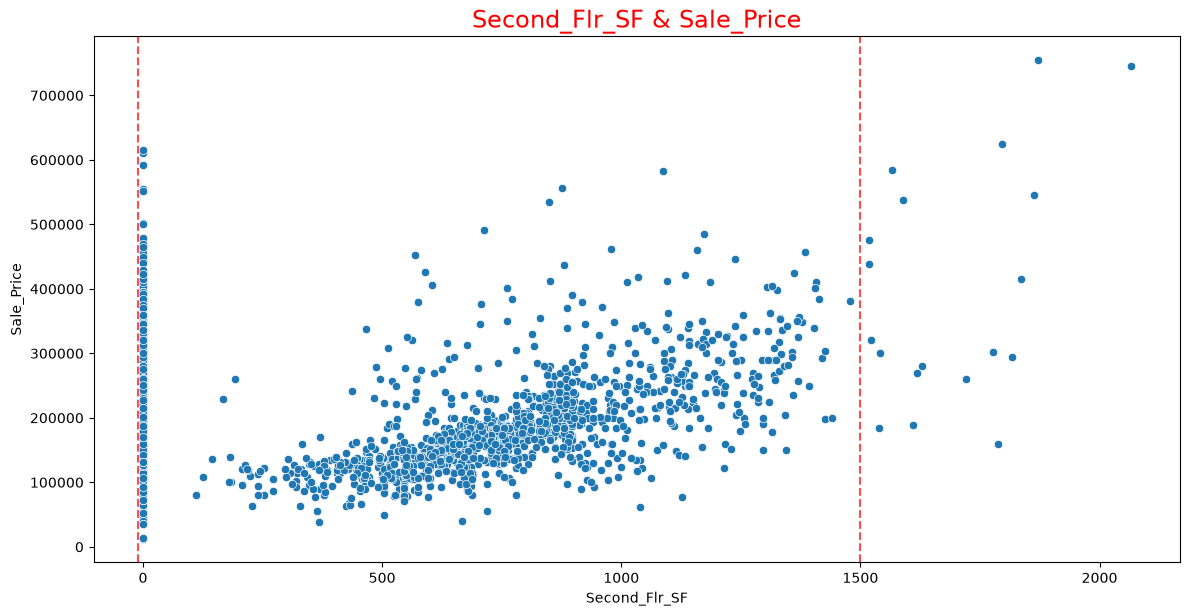

In [575]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Second_Flr_SF', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Second_Flr_SF & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=1500, color='red', linestyle='--', alpha=0.7)

### Second Floor Area Analysis

The scatter plot shows a positive relationship between `Second_Flr_SF` and `Sale_Price`, although the relationship is more variable than for some other area-related features.

A large number of observations have little or no second-floor area, while houses with larger second-floor areas generally tend to have higher sale prices.

The spread of sale prices becomes wider as the second-floor area increases, indicating that this feature alone does not completely explain differences in house prices.

Overall, `Second_Flr_SF` provides useful information for the regression model, but its relationship with `Sale_Price` appears less consistent than some of the other living-area features.


Text(0.5, 1.0, 'Garage_Cars & Sale_Price')

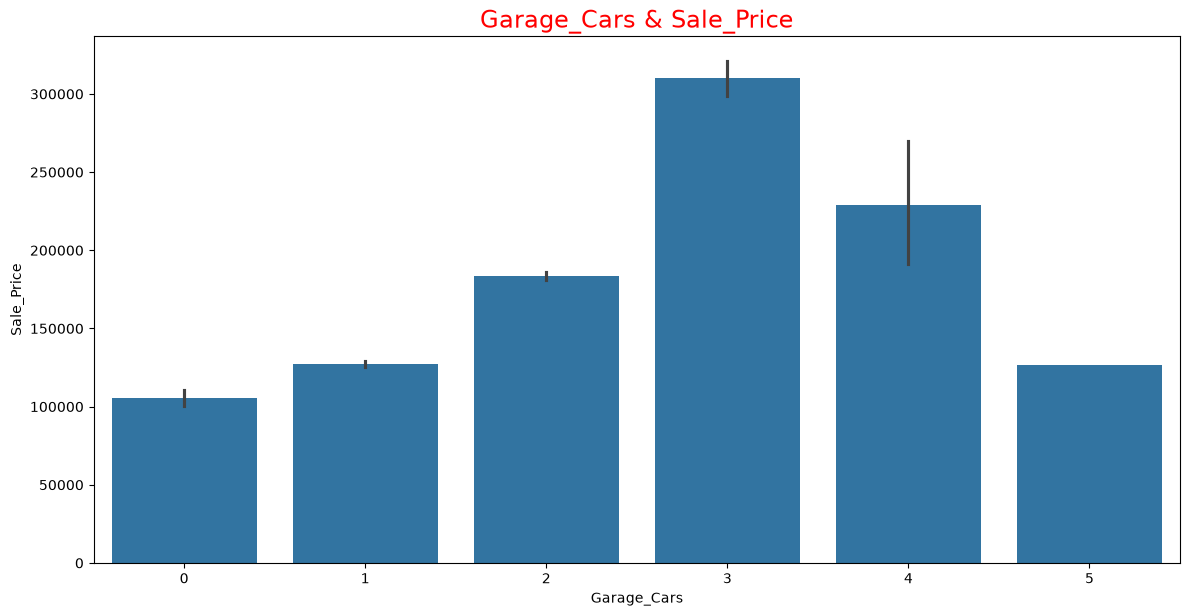

In [576]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='Garage_Cars', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Garage_Cars & Sale_Price', size=17, color='red')

### Garage Capacity Analysis

The bar plot compares the average `Sale_Price` across different values of `Garage_Cars`, representing the number of cars that can be accommodated in the garage.

The average sale price generally increases as garage capacity increases, indicating a noticeable difference in house prices across garage capacities.

However, the categories do not necessarily contain the same number of observations, so the average price of less frequent categories should be interpreted with caution.

Overall, `Garage_Cars` appears to be an informative feature for predicting `Sale_Price`, as garage capacity is associated with differences in average house prices.


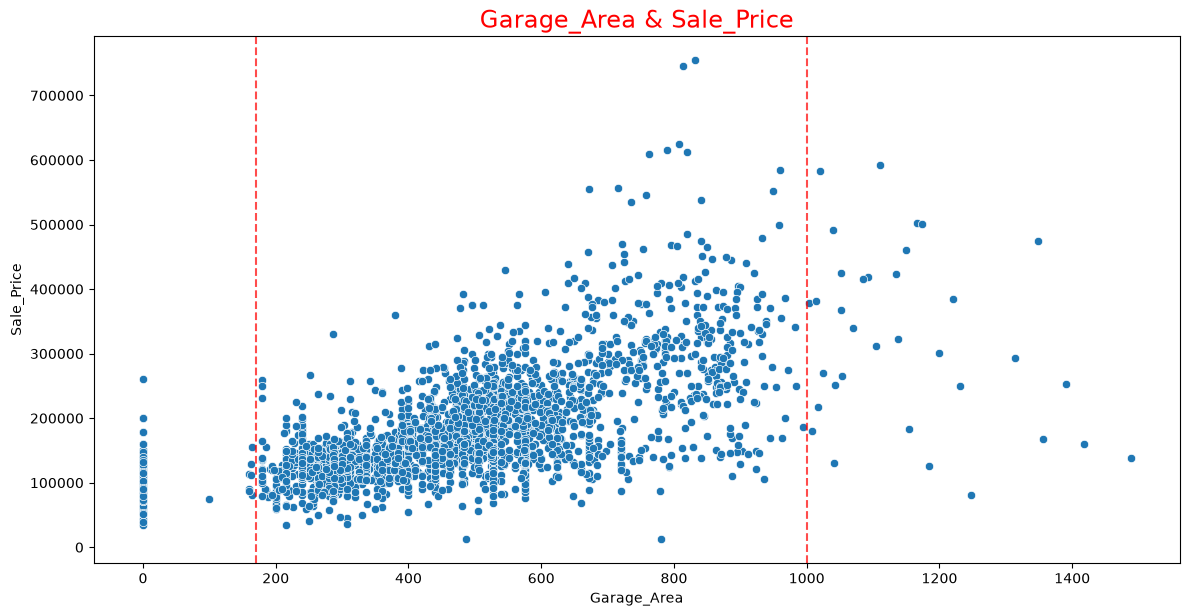

In [577]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Garage_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Garage_Area & Sale_Price', size=17, color='red')
# ax.set_xlim(1940, 2020)

ax.axvline(x=170, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=1000, color='red', linestyle='--', alpha=0.7)

### Garage Area Analysis

The scatter plot shows a generally positive relationship between `Garage_Area` and `Sale_Price`. Houses with larger garage areas tend to have higher sale prices.

Many observations are concentrated within a relatively common range of garage areas, while very small and very large garage areas are less frequent.

The plot highlights values below approximately **170 square feet** and above approximately **1,000 square feet** as observations that may require additional investigation during outlier analysis.

Overall, `Garage_Area` provides useful information about differences in `Sale_Price`.


In [578]:
df['TotRms_AbvGrd'].value_counts()

TotRms_AbvGrd
6     844
7     649
5     586
8     347
4     203
9     143
10     80
11     32
3      26
12     16
13      1
2       1
15      1
14      1
Name: count, dtype: int64

Text(0.5, 1.0, 'TotRms_AbvGrd & Sale_Price')

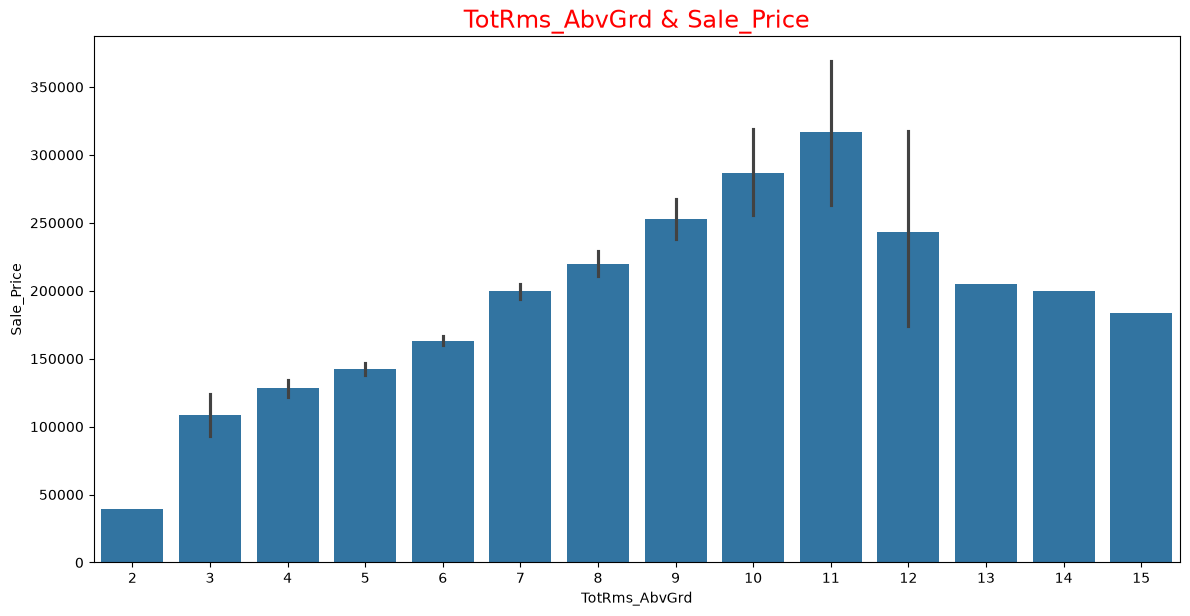

In [579]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='TotRms_AbvGrd', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('TotRms_AbvGrd & Sale_Price', size=17, color='red')

### Garage Area Analysis

The scatter plot shows a generally positive relationship between `Garage_Area` and `Sale_Price`. Houses with larger garage areas tend to have higher sale prices.

Many observations are concentrated within a relatively common range of garage areas, while very small and very large garage areas are less frequent.

The plot highlights values below approximately **170 square feet** and above approximately **1,000 square feet** as observations that may require additional investigation during outlier analysis.

Overall, `Garage_Area` provides useful information about differences in `Sale_Price`.


Text(0.5, 1.0, 'Fireplaces & Sale_Price')

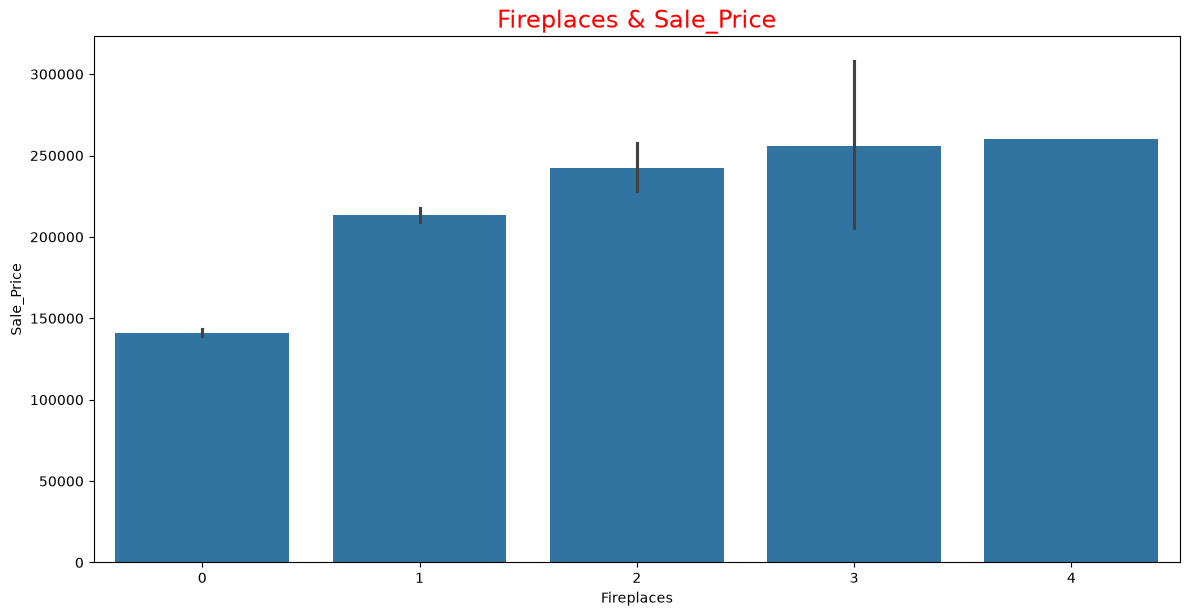

In [580]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='Fireplaces', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Fireplaces & Sale_Price', size=17, color='red')

### Fireplaces Analysis

The bar plot compares the average `Sale_Price` across different numbers of fireplaces.

The average sale price generally increases as the number of fireplaces increases, although the number of observations becomes smaller for higher fireplace counts.

This means that the averages for categories with very few observations should be interpreted carefully.

Overall, `Fireplaces` shows a noticeable relationship with `Sale_Price` and may provide useful information for the regression model.


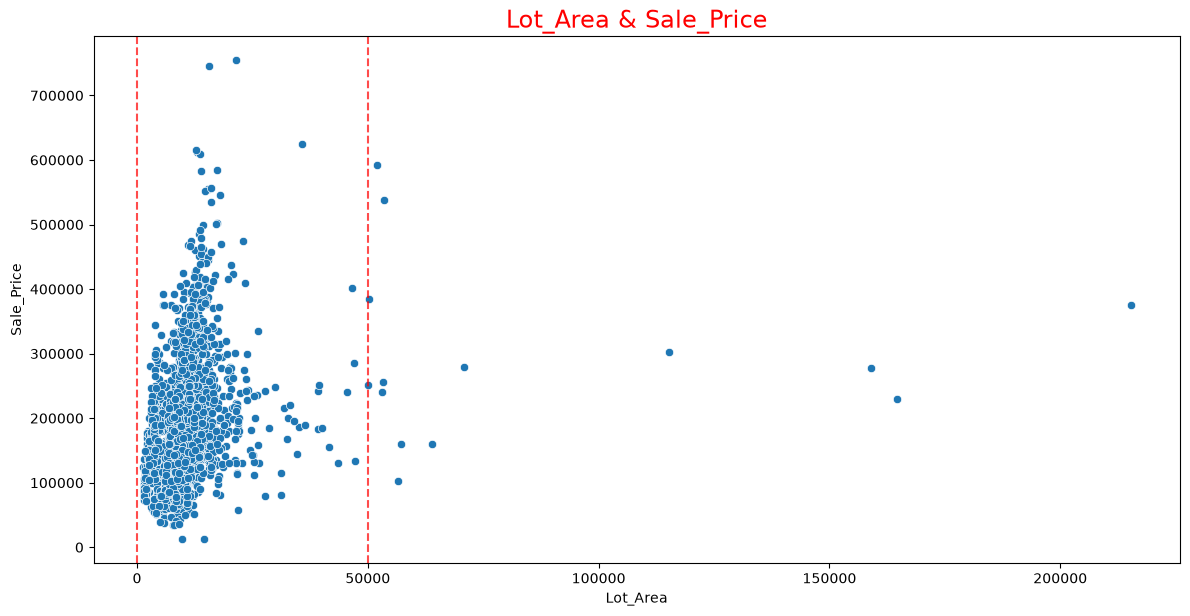

In [581]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Lot_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Lot_Area & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=50000, color='red', linestyle='--', alpha=0.7)

### Lot Area Analysis

The scatter plot shows a positive relationship between `Lot_Area` and `Sale_Price`, although the relationship is weaker and more dispersed than for some of the main living-area features.

Most houses are concentrated within a relatively smaller range of lot sizes, while a limited number of properties have substantially larger lots.

The wider spread of sale prices suggests that lot size alone does not fully explain house prices. Other characteristics of the property also contribute to the observed price differences.

Overall, `Lot_Area` provides useful information for the regression task, while its relatively dispersed relationship should be considered during modeling.


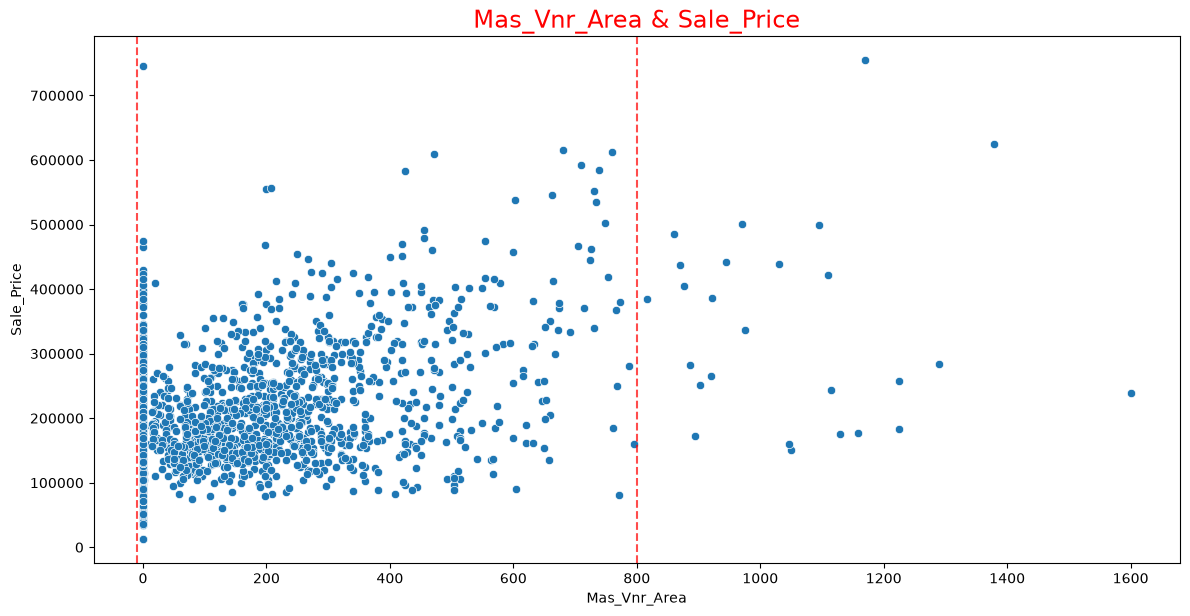

In [582]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df, 
    x='Mas_Vnr_Area', 
    y='Sale_Price'
)
fig.tight_layout()

ax.set_title('Mas_Vnr_Area & Sale_Price', size=17, color='red')

ax.axvline(x=-10, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=800, color='red', linestyle='--', alpha=0.7)

### Masonry Veneer Area Analysis

The scatter plot shows a generally positive relationship between `Mas_Vnr_Area` and `Sale_Price`, although the observations are relatively dispersed.

A considerable number of houses have little or no masonry veneer area, while a smaller number of houses have larger veneer areas.

The wider spread of sale prices at similar masonry veneer areas indicates that this feature alone does not strongly determine house price.

Overall, `Mas_Vnr_Area` may provide useful additional information for predicting `Sale_Price`, but its relationship appears weaker and more variable than features such as `Gr_Liv_Area` or `Total_Bsmt_SF`.


## Numerical Features Analysis

The numerical features were visualized to investigate their distributions and relationships with `Sale_Price`.

The scatter plots reveal that several property-size features, including `Gr_Liv_Area`, `Total_Bsmt_SF`, `First_Flr_SF`, and `Garage_Area`, generally show a positive relationship with `Sale_Price`. In other words, houses with larger areas tend to have higher sale prices, although the strength of these relationships varies across features.

The time-related features, `Year_Built` and `Year_Remod_Add`, also show a general tendency toward higher sale prices for newer properties and more recently remodeled houses. However, the observations are dispersed, indicating that these features alone cannot fully explain house prices.

The bar plots for `Garage_Cars`, `TotRms_AbvGrd`, and `Fireplaces` show differences in average `Sale_Price` across their respective values. These differences suggest that house capacity, layout, and additional features can provide useful information for predicting sale prices.

Some numerical features also contain observations that are considerably different from the main concentration of the data. These observations are especially noticeable in features such as `Gr_Liv_Area`, `Total_Bsmt_SF`, `First_Flr_SF`, `Garage_Area`, and `Lot_Area`. At this stage, these values are treated as potential outliers rather than errors and will be investigated separately.

Overall, the numerical feature analysis indicates that **property size, construction and remodeling year, and additional house characteristics contain valuable information about `Sale_Price`**. The observed relationships and potential extreme values provide a strong basis for the next stage of the analysis: **Outlier Analysis**.


In [583]:
def detect_outliers_iqr(df, columns):
    outlier_summary = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': len(outliers) / len(df) * 100,
            'Mean': df[col].mean(),
            'Variance': df[col].var(),
            'Std': df[col].std(),
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

    return pd.DataFrame(outlier_summary)

In [584]:
outlier_summary = detect_outliers_iqr(
    df,
    numerical_features
)

outlier_summary.sort_values(
    'Outlier_Count',
    ascending=False
)

,Feature,Outlier_Count,Outlier_Percentage,Mean,Variance,Std,IQR,Lower_Bound,Upper_Bound
25,Enclosed_Porch,459,15.665529,23.011604,4.113819e+03,64.139059,0.000000,0.000000,0.000000
6,BsmtFin_SF_2,351,11.979522,49.705461,2.860905e+04,169.142089,0.000000,0.000000,0.000000
27,Screen_Porch,256,8.737201,16.002048,3.145793e+03,56.087370,0.000000,0.000000,0.000000
4,Mas_Vnr_Area,203,6.928328,101.096928,3.191030e+04,178.634545,162.750000,-244.125000,406.875000
14,Bsmt_Half_Bath,175,5.972696,0.061092,6.011079e-02,0.245175,0.000000,0.000000,0.000000
24,Open_Porch_SF,159,5.426621,47.533447,4.554009e+03,67.483400,70.000000,-105.000000,175.000000
32,Sale_Price,137,4.675768,180796.060068,6.381884e+09,79886.692357,84000.000000,3500.000000,339500.000000
18,Kitchen_AbvGr,134,4.573379,1.044369,4.582864e-02,0.214076,0.000000,1.000000,1.000000
1,Lot_Area,127,4.334471,10147.921843,6.209468e+07,7880.017759,4115.000000,1267.750000,17727.750000
8,Total_Bsmt_SF,124,4.232082,1051.255631,1.944528e+05,440.968018,508.500000,30.250000,2064.250000


In [585]:
df['Enclosed_Porch'].value_counts().sort_index()

Enclosed_Porch
0       2471
16         1
18         1
19         1
20         2
        ... 
429        1
432        1
552        1
584        1
1012       1
Name: count, Length: 183, dtype: int64

In [586]:
enclosed_porch_outliers = df[
    df['Enclosed_Porch'] > 0
][['Enclosed_Porch', 'Sale_Price']].sort_values(
    'Enclosed_Porch',
    ascending=False
)

enclosed_porch_outliers

,Enclosed_Porch,Sale_Price
2089,1012,228500
2223,584,201000
2570,552,235000
660,432,142900
2858,429,195000
...,...,...
1976,20,89500
1318,20,122000
2216,19,220000
186,18,76500


In [587]:
def identify_real_outliers(df, columns, threshold=1.5):
    results = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Ignore features with zero IQR
        if IQR == 0:
            continue

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        if len(outliers) > 0:
            results.append({
                'Feature': col,
                'Outlier_Count': len(outliers),
                'Outlier_Percentage': len(outliers) / len(df) * 100,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'Min_Outlier': outliers[col].min(),
                'Max_Outlier': outliers[col].max()
            })

    return pd.DataFrame(results).sort_values(
        'Outlier_Count',
        ascending=False
    )

In [588]:
numerical_features = df.select_dtypes(
    include='number'
).columns.drop('Sale_Price')

real_outliers = identify_real_outliers(
    df,
    numerical_features
)

real_outliers

,Feature,Outlier_Count,Outlier_Percentage,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Min_Outlier,Max_Outlier
3,Mas_Vnr_Area,203,6.928328,0.00,162.75,162.75,-244.125,406.875,408,1600
17,Open_Porch_SF,159,5.426621,0.00,70.00,70.00,-105.000,175.000,176,742
1,Lot_Area,127,4.334471,7440.25,11555.25,4115.00,1267.750,17727.750,17755,215245
5,Total_Bsmt_SF,124,4.232082,793.00,1301.50,508.50,30.250,2064.250,0,6110
11,Bedroom_AbvGr,78,2.662116,2.00,3.00,1.00,0.500,4.500,0,8
8,Gr_Liv_Area,75,2.559727,1126.00,1742.75,616.75,200.875,2667.875,2668,5642
16,Wood_Deck_SF,67,2.286689,0.00,168.00,168.00,-252.000,420.000,421,1424
4,Bsmt_Unf_SF,56,1.911263,219.00,801.75,582.75,-655.125,1675.875,1678,2336
12,TotRms_AbvGrd,51,1.740614,5.00,7.00,2.00,2.000,10.000,11,15
6,First_Flr_SF,43,1.467577,876.25,1384.00,507.75,114.625,2145.625,2151,5095


In [589]:
outlier_bounds = {
    'Mas_Vnr_Area': (-244.125, 406.875),
    'Open_Porch_SF': (-105, 175),
    'Lot_Area': (1267.75, 17727.75),
    'Total_Bsmt_SF': (30.25, 2064.25),
    'Bedroom_AbvGr': (0.5, 4.5),
    'Gr_Liv_Area': (200.875, 2667.875),
    'Wood_Deck_SF': (-252, 420),
    'Bsmt_Unf_SF': (-655.125, 1675.875),
    'TotRms_AbvGrd': (2, 10),
    'First_Flr_SF': (114.625, 2145.625),
    'Garage_Area': (-64, 960),
    'Lot_Frontage': (-9.5, 130.5),
    'Garage_Cars': (-0.5, 3.5),
    'Fireplaces': (-1.5, 2.5),
    'Year_Built': (1883.5, 2071.5),
    'Second_Flr_SF': (-1055.625, 1759.375),
    'Full_Bath': (-0.5, 3.5),
    'Bsmt_Full_Bath': (-1.5, 2.5)
}

for feature, (lower, upper) in outlier_bounds.items():
    df = df[
        (df[feature] >= lower) &
        (df[feature] <= upper)
    ].copy()

print(f"Remaining rows: {len(df)}")
print(f"Rows removed: {2930 - len(df)}")

Remaining rows: 2222
Rows removed: 708


In [590]:
numerical_features = df.select_dtypes(
    include='number'
).columns.drop('Sale_Price')

real_outliers = identify_real_outliers(
    df,
    numerical_features
)

real_outliers

,Feature,Outlier_Count,Outlier_Percentage,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Min_Outlier,Max_Outlier
2,Mas_Vnr_Area,142,6.390639,0.00,108.75,108.75,-163.125,271.875,272,406
1,Lot_Area,81,3.645365,7200.00,10711.50,3511.50,1932.750,15978.750,1300,17600
9,Open_Porch_SF,74,3.330333,0.00,56.00,56.00,-84.000,140.000,141,175
4,Total_Bsmt_SF,22,0.990099,785.00,1199.75,414.75,162.875,1821.875,105,2006
8,Wood_Deck_SF,16,0.720072,0.00,158.00,158.00,-237.000,395.000,400,418
3,Bsmt_Unf_SF,16,0.720072,230.25,783.75,553.50,-600.000,1614.000,1615,1670
6,Gr_Liv_Area,16,0.720072,1082.00,1637.50,555.50,248.750,2470.750,2473,2654
5,First_Flr_SF,15,0.675068,855.00,1277.75,422.75,220.875,1911.875,1922,2117
0,Lot_Frontage,10,0.450045,43.00,75.00,32.00,-5.000,123.000,124,130
7,Garage_Area,10,0.450045,308.00,553.50,245.50,-60.250,921.750,923,947


In [591]:
df.shape

(2222, 81)

In [592]:
important_features = [
    'Lot_Area',
    'Total_Bsmt_SF',
    'Gr_Liv_Area',
    'First_Flr_SF',
    'Garage_Area',
    'Mas_Vnr_Area'
]

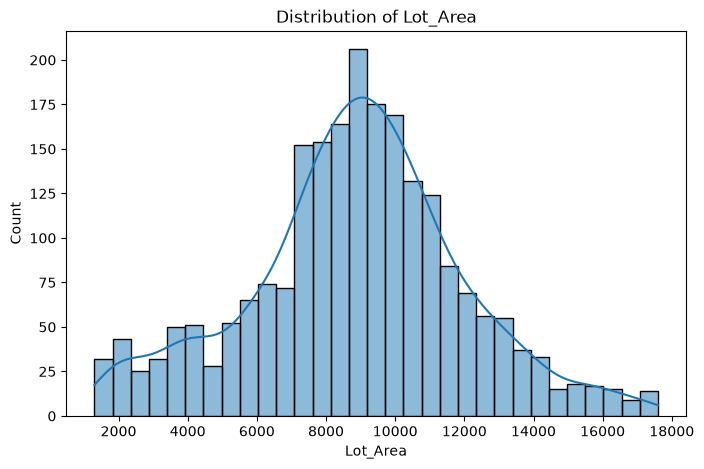

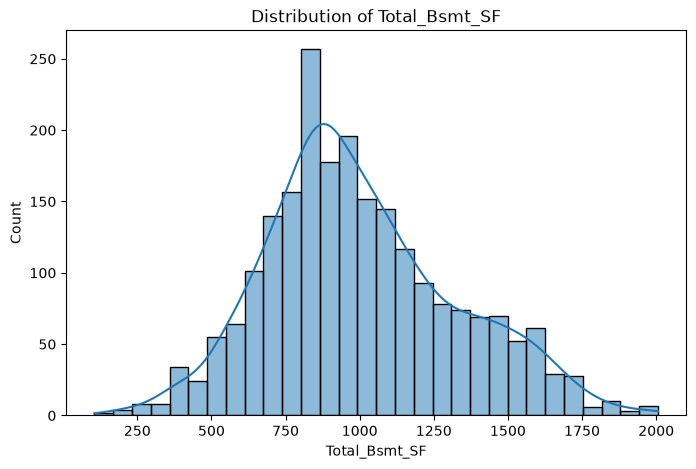

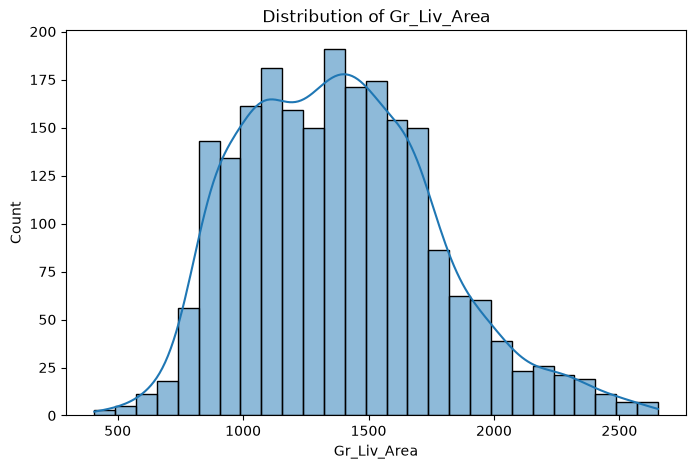

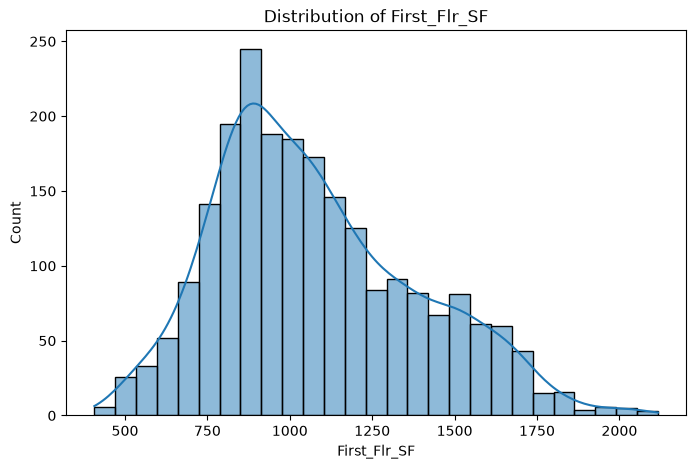

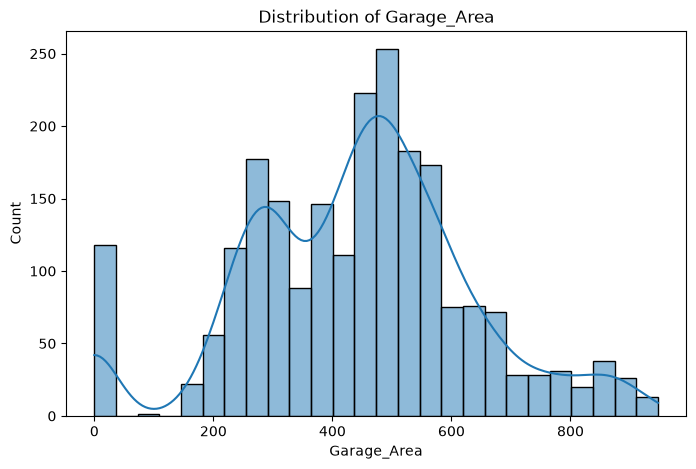

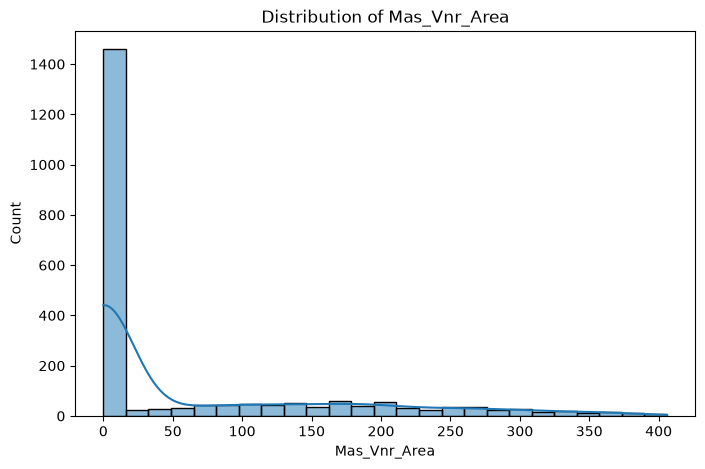

In [593]:
for feature in important_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )
    
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [594]:
df.dtypes.value_counts()

int64       33
category     3
category     2
category     2
category     2
float64      2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [595]:
df.select_dtypes(include='category').columns

Index(['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape',
       'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood',
       'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style',
       'Overall_Qual', 'Overall_Cond', 'Roof_Style', 'Roof_Matl',
       'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'Heating_QC',
       'Central_Air', 'Electrical', 'Kitchen_Qual', 'Functional',
       'Fireplace_Qu', 'Garage_Type', 'Garage_Finish', 'Garage_Qual',
       'Garage_Cond', 'Paved_Drive', 'Pool_QC', 'Fence', 'Misc_Feature',
       'Sale_Type', 'Sale_Condition'],
      dtype='str')

In [596]:
new_feature = df[categorical_features].nunique().sort_values(ascending=False)
new_feature

Neighborhood      28
MS_SubClass       16
Exterior_2nd      16
Exterior_1st      15
Sale_Type         10
Overall_Qual      10
Condition_1        9
Overall_Cond       9
House_Style        8
Garage_Type        7
BsmtFin_Type_2     6
Roof_Style         6
Condition_2        6
Fireplace_Qu       6
Electrical         6
Garage_Qual        6
Sale_Condition     6
Garage_Cond        6
BsmtFin_Type_1     6
Functional         6
Fence              5
Lot_Config         5
MS_Zoning          5
Heating_QC         5
Kitchen_Qual       5
Bsmt_Cond          5
Foundation         5
Bsmt_Exposure      5
Bldg_Type          5
Exter_Cond         5
Bsmt_Qual          5
Roof_Matl          4
Heating            4
Garage_Finish      4
Land_Contour       4
Lot_Shape          4
Mas_Vnr_Type       4
Exter_Qual         4
Misc_Feature       4
Pool_QC            4
Alley              3
Land_Slope         3
Paved_Drive        3
Street             2
Central_Air        2
Utilities          1
dtype: int64

In [597]:
df['Utilities'].value_counts()

Utilities
AllPub    2222
NoSeWa       0
NoSewr       0
Name: count, dtype: int64

In [598]:
df2 = data.frame
df2['Utilities'].value_counts()

Utilities
AllPub    2927
NoSewr       2
NoSeWa       1
Name: count, dtype: int64

In [599]:
categorical_features2 = df2.select_dtypes(include='category').columns
categorical_features2

Index(['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape',
       'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood',
       'Condition_1', 'Condition_2', 'Bldg_Type', 'House_Style',
       'Overall_Qual', 'Overall_Cond', 'Roof_Style', 'Roof_Matl',
       'Exterior_1st', 'Exterior_2nd', 'Mas_Vnr_Type', 'Exter_Qual',
       'Exter_Cond', 'Foundation', 'Bsmt_Qual', 'Bsmt_Cond', 'Bsmt_Exposure',
       'BsmtFin_Type_1', 'BsmtFin_Type_2', 'Heating', 'Heating_QC',
       'Central_Air', 'Electrical', 'Kitchen_Qual', 'Functional',
       'Fireplace_Qu', 'Garage_Type', 'Garage_Finish', 'Garage_Qual',
       'Garage_Cond', 'Paved_Drive', 'Pool_QC', 'Fence', 'Misc_Feature',
       'Sale_Type', 'Sale_Condition'],
      dtype='str')

In [600]:
outlier_feaure = df2[categorical_features2].nunique().sort_values(ascending=False)
outlier_feaure

Neighborhood      28
Exterior_2nd      17
Exterior_1st      16
MS_SubClass       16
Sale_Type         10
Overall_Qual      10
Condition_1        9
Overall_Cond       9
Roof_Matl          8
Functional         8
House_Style        8
Condition_2        8
BsmtFin_Type_2     7
MS_Zoning          7
BsmtFin_Type_1     7
Garage_Type        7
Garage_Qual        6
Fireplace_Qu       6
Garage_Cond        6
Bsmt_Cond          6
Foundation         6
Roof_Style         6
Sale_Condition     6
Misc_Feature       6
Heating            6
Bsmt_Qual          6
Electrical         6
Bsmt_Exposure      5
Bldg_Type          5
Lot_Config         5
Fence              5
Pool_QC            5
Kitchen_Qual       5
Heating_QC         5
Mas_Vnr_Type       5
Exter_Cond         5
Land_Contour       4
Lot_Shape          4
Exter_Qual         4
Garage_Finish      4
Alley              3
Land_Slope         3
Paved_Drive        3
Utilities          3
Street             2
Central_Air        2
dtype: int64

In [601]:
diffrence_cat =pd.DataFrame([
    (pd.Series(outlier_feaure, name='outlier_feaure')),
    (pd.Series(new_feature, name='new_feature')),
]).T
diffrence_cat['diffrence'] = (outlier_feaure - new_feature)
diffrence_cat.sort_values('new_feature', ascending=False)

,outlier_feaure,new_feature,diffrence
Neighborhood,28,28,0
Exterior_2nd,17,16,1
MS_SubClass,16,16,0
Exterior_1st,16,15,1
Sale_Type,10,10,0
Overall_Qual,10,10,0
Condition_1,9,9,0
Overall_Cond,9,9,0
House_Style,8,8,0
Garage_Type,7,7,0


In [602]:
df.shape

(2222, 81)

In [603]:
print(f"Roof_Matl_df2: {df2['Roof_Matl'].value_counts()}\n")
print(f"Roof_Matl_df: {df['Roof_Matl'].value_counts()}")

Roof_Matl_df2: Roof_Matl
CompShg    2887
Tar&Grv      23
WdShake       9
WdShngl       7
ClyTile       1
Membran       1
Metal         1
Roll          1
Name: count, dtype: int64

Roof_Matl_df: Roof_Matl
CompShg    2209
Tar&Grv      10
WdShake       2
WdShngl       1
ClyTile       0
Membran       0
Metal         0
Roll          0
Name: count, dtype: int64


In [604]:
df['Central_Air'].unique()

['Y', 'N']
Categories (2, str): ['N', 'Y']

In [605]:
df['Street'].unique()

['Pave', 'Grvl']
Categories (2, str): ['Grvl', 'Pave']

In [606]:
def show_categories(features):
    for feature in features:
        values = df[feature].unique()

        print(f"{feature:<20} | {len(values):>2} categories | {', '.join(map(str, values))}")

show_categories(new_feature.index)

Neighborhood         | 28 categories | North_Ames, Gilbert, Stone_Brook, Northwest_Ames, Somerset, Briardale, Northpark_Villa, Northridge_Heights, Bloomington_Heights, Northridge, Sawyer_West, Sawyer, Greens, Brookside, Old_Town, Iowa_DOT_and_Rail_Road, Clear_Creek, South_and_West_of_Iowa_State_University, Edwards, College_Creek, Crawford, Blueste, Mitchell, Timberland, Meadow_Village, Veenker, Green_Hills, Landmark
MS_SubClass          | 16 categories | One_Story_1946_and_Newer_All_Styles, Two_Story_1946_and_Newer, One_Story_PUD_1946_and_Newer, Split_Foyer, Two_Story_PUD_1946_and_Newer, Split_or_Multilevel, One_Story_1945_and_Older, One_and_Half_Story_Finished_All_Ages, Duplex_All_Styles_and_Ages, Two_Family_conversion_All_Styles_and_Ages, One_and_Half_Story_Unfinished_All_Ages, Two_Story_1945_and_Older, Two_and_Half_Story_All_Ages, PUD_Multilevel_Split_Level_Foyer, One_Story_with_Finished_Attic_All_Ages, One_and_Half_Story_PUD_All_Ages
Exterior_2nd         | 16 categories | VinylSd, 

In [607]:
ordinal_features = [
    'Overall_Qual',
    'Overall_Cond',
    'Exter_Qual',
    'Exter_Cond',
    'Bsmt_Qual',
    'Bsmt_Cond',
    'Bsmt_Exposure',
    'BsmtFin_Type_1',
    'BsmtFin_Type_2',
    'Heating_QC',
    'Kitchen_Qual',
    'Garage_Qual',
    'Garage_Cond',
    'Garage_Finish',
    'Fireplace_Qu',
    'Functional'
]

In [608]:
nominal_features = [
    'Neighborhood',
    'MS_SubClass',
    'Exterior_1st',
    'Exterior_2nd',
    'Sale_Type',
    'Condition_1',
    'Condition_2',
    'House_Style',
    'Garage_Type',
    'Roof_Style',
    'Electrical',
    'Sale_Condition',
    'Fence',
    'Lot_Config',
    'MS_Zoning',
    'Street',
    'Alley',
    'Land_Slope',
    'Paved_Drive',
    'Roof_Matl',
    'Heating',
    'Land_Contour',
    'Lot_Shape',
    'Mas_Vnr_Type',
    'Misc_Feature',
    'Pool_QC',
    'Foundation',
    'Bldg_Type'
]
len(nominal_features)

28

In [609]:
binary_features = ['Central_Air']

In [610]:
df = df.drop(columns=['Utilities'])

## Categorical Feature Preparation

The categorical features were analyzed based on their **cardinality** and the presence of an inherent ordering between categories.

### Feature Encoding Strategy

Categorical features were divided into three groups:

* **Ordinal Features:** Features with a meaningful order between categories.
* **Nominal Features:** Features where categories have no inherent order.
* **Binary Features:** Features containing only two categories.

For the encoding stage:

* **Ordinal features** will be encoded while preserving their natural order.
* **Nominal features** will be encoded using **One-Hot Encoding**.
* `Central_Air` will be treated as a binary feature.
* `Utilities` was removed because only one category remained after outlier removal, making it a constant feature with no predictive information.

This separation ensures that the categorical encoding strategy is appropriate for the underlying structure of each feature and avoids introducing artificial relationships between nominal categories.


## **Central_Air**

In [611]:
df['Central_Air'].cat.categories

Index(['N', 'Y'], dtype='str')

In [612]:
df['Central_Air'] = df['Central_Air'].cat.codes

## **Overall_Qual**

In [613]:
df['Overall_Qual'].cat.categories

Index(['Above_Average', 'Average', 'Below_Average', 'Excellent', 'Fair',
       'Good', 'Poor', 'Very_Excellent', 'Very_Good', 'Very_Poor'],
      dtype='str')

In [614]:
overall_qual_order = [
    'Very_Poor',
    'Poor',
    'Fair',
    'Below_Average',
    'Average',
    'Above_Average',
    'Good',
    'Very_Good',
    'Excellent',
    'Very_Excellent'
]
df['Overall_Qual'] = pd.Categorical(
    df['Overall_Qual'],
    categories=overall_qual_order,
    ordered=True
)

In [615]:
df['Overall_Qual'].cat.categories

Index(['Very_Poor', 'Poor', 'Fair', 'Below_Average', 'Average',
       'Above_Average', 'Good', 'Very_Good', 'Excellent', 'Very_Excellent'],
      dtype='str')

In [616]:
df['Overall_Qual'] = df['Overall_Qual'].cat.codes

## **Overall_Cond**

In [617]:
df['Overall_Cond'].cat.categories

Index(['Above_Average', 'Average', 'Below_Average', 'Excellent', 'Fair',
       'Good', 'Poor', 'Very_Good', 'Very_Poor'],
      dtype='str')

In [618]:
overall_cond_order = [
    'Very_Poor',
    'Poor',
    'Fair',
    'Below_Average',
    'Average',
    'Above_Average',
    'Good',
    'Very_Good',
    'Excellent'
]

df['Overall_Cond'] = pd.Categorical(
    df['Overall_Cond'],
    categories=overall_cond_order,
    ordered=True
)

In [619]:
df['Overall_Cond'].cat.categories

Index(['Very_Poor', 'Poor', 'Fair', 'Below_Average', 'Average',
       'Above_Average', 'Good', 'Very_Good', 'Excellent'],
      dtype='str')

In [620]:
df['Overall_Cond'] = df['Overall_Cond'].cat.codes

## **Exter_Qual**

In [621]:
df['Exter_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Typical'], dtype='str')

In [622]:
exter_qual_order = [
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Exter_Qual'],
    categories=exter_qual_order,
    ordered=True
)


['Typical', 'Typical', 'Typical', 'Typical', 'Good', ..., 'Typical', 'Typical', 'Typical', 'Typical', 'Typical']
Length: 2222
Categories (4, str): ['Fair' < 'Typical' < 'Good' < 'Excellent']

In [623]:
df['Exter_Qual']= df['Exter_Qual'].cat.codes

## **Exter_Cond**

In [624]:
df['Exter_Cond'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Poor', 'Typical'], dtype='str')

In [625]:
exter_cond_order = [
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

df['Exter_Cond'] =pd.Categorical(
    df['Exter_Cond'],
    categories=exter_cond_order,
    ordered=True
)

In [626]:
df['Exter_Cond'] = df['Exter_Cond'].cat.codes

## **Bsmt_Qual**

In [627]:
df['Bsmt_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Basement', 'Poor', 'Typical'], dtype='str')

In [628]:
bsmt_qual_order = [
    'No_Basement',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Bsmt_Qual'],
    categories=bsmt_qual_order,
    ordered=True
)

['Typical', 'Typical', 'Good', 'Typical', 'Good', ..., 'Typical', 'Good', 'Good', 'Good', 'Good']
Length: 2222
Categories (6, str): ['No_Basement' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [629]:
df['Bsmt_Qual'] = df['Bsmt_Qual'].cat.codes

## **Bsmt_Cond**

In [630]:
df['Bsmt_Cond'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Basement', 'Poor', 'Typical'], dtype='str')

In [631]:
bsmt_cond_order = [
    'No_Basement',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Bsmt_Cond'],
    categories=bsmt_cond_order,
    ordered=True
)

['Typical', 'Typical', 'Typical', 'Typical', 'Typical', ..., 'Typical', 'Typical', 'Typical', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Basement' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [632]:
df['Bsmt_Cond'] = df['Bsmt_Cond'].cat.codes

## **Bsmt_Exposure**

In [633]:
df['Bsmt_Exposure'].cat.categories

Index(['Av', 'Gd', 'Mn', 'No', 'No_Basement'], dtype='str')

In [634]:
bsmt_exposure_order = [
    'No_Basement',
    'No',
    'Mn',
    'Av',
    'Gd'
]

pd.Categorical(
    df['Bsmt_Exposure'],
    categories=bsmt_exposure_order,
    ordered=True
)

['No', 'No', 'No', 'No', 'Mn', ..., 'Av', 'Av', 'Av', 'Av', 'Av']
Length: 2222
Categories (5, str): ['No_Basement' < 'No' < 'Mn' < 'Av' < 'Gd']

In [635]:
df['Bsmt_Exposure'] = df['Bsmt_Exposure'].cat.codes

## **BsmtFin_Type_1**

In [636]:
df['BsmtFin_Type_1'].cat.categories

Index(['ALQ', 'BLQ', 'GLQ', 'LwQ', 'No_Basement', 'Rec', 'Unf'], dtype='str')

In [637]:
bsmtfin_type_1_order = [
    'No_Basement',
    'Unf',
    'LwQ',
    'Rec',
    'BLQ',
    'ALQ',
    'GLQ'
]

pd.Categorical(
    df['BsmtFin_Type_1'],
    categories=bsmtfin_type_1_order,
    ordered=True
)

['Rec', 'ALQ', 'GLQ', 'GLQ', 'GLQ', ..., 'GLQ', 'BLQ', 'GLQ', 'ALQ', 'LwQ']
Length: 2222
Categories (7, str): ['No_Basement' < 'Unf' < 'LwQ' < 'Rec' < 'BLQ' < 'ALQ' < 'GLQ']

In [638]:
df['BsmtFin_Type_1'] = df['BsmtFin_Type_1'].cat.codes

## **BsmtFin_Type_2**

In [639]:
df['BsmtFin_Type_2'].cat.categories

Index(['ALQ', 'BLQ', 'GLQ', 'LwQ', 'No_Basement', 'Rec', 'Unf'], dtype='str')

In [640]:
bsmtfin_type_2_order = [
    'No_Basement',
    'Unf',
    'LwQ',
    'Rec',
    'BLQ',
    'ALQ',
    'GLQ'
]

pd.Categorical(
    df['BsmtFin_Type_2'],
    categories=bsmtfin_type_2_order,
    ordered=True
)


['LwQ', 'Unf', 'Unf', 'Unf', 'Unf', ..., 'Unf', 'ALQ', 'Unf', 'LwQ', 'Unf']
Length: 2222
Categories (7, str): ['No_Basement' < 'Unf' < 'LwQ' < 'Rec' < 'BLQ' < 'ALQ' < 'GLQ']

In [641]:
df['BsmtFin_Type_2'] = df['BsmtFin_Type_2'].cat.codes

## **Heating_QC**

In [642]:
df['Heating_QC'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Poor', 'Typical'], dtype='str')

In [643]:
heating_qc_order = [
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]
pd.Categorical(
    df['Heating_QC'],
    categories=heating_qc_order,
    ordered=True
)


['Typical', 'Typical', 'Good', 'Excellent', 'Excellent', ..., 'Typical', 'Typical', 'Typical', 'Good', 'Excellent']
Length: 2222
Categories (5, str): ['Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [644]:
df['Heating_QC'] = df['Heating_QC'].cat.codes

## **Kitchen_Qual**

In [645]:
df['Kitchen_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'Poor', 'Typical'], dtype='str')

In [646]:
kitchen_qual_order = [
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Kitchen_Qual'],
    categories=kitchen_qual_order,
    ordered=True
)


['Typical', 'Good', 'Typical', 'Good', 'Good', ..., 'Typical', 'Typical', 'Typical', 'Typical', 'Typical']
Length: 2222
Categories (5, str): ['Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [647]:
df['Kitchen_Qual'] = df['Kitchen_Qual'].cat.codes

## **Garage_Qual**

In [648]:
df['Garage_Qual'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Garage', 'Poor', 'Typical'], dtype='str')

In [649]:
garage_qual_order = [
    'No_Garage',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Garage_Qual'],
    categories=garage_qual_order,
    ordered=True
)

['Typical', 'Typical', 'Typical', 'Typical', 'Typical', ..., 'Typical', 'Typical', 'No_Garage', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Garage' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [650]:
df['Garage_Qual'] = df['Garage_Qual'].cat.codes

## **Garage_Cond**

In [651]:
df['Garage_Cond'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Garage', 'Poor', 'Typical'], dtype='str')

In [652]:
garage_cond_order = [
    'No_Garage',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Garage_Cond'],
    categories=garage_cond_order,
    ordered=True
)

['Typical', 'Typical', 'Typical', 'Typical', 'Typical', ..., 'Typical', 'Typical', 'No_Garage', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Garage' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [653]:
df['Garage_Cond'] = df['Garage_Cond'].cat.codes

## **Garage_Finish**

In [654]:
df['Garage_Finish'].cat.categories

Index(['Fin', 'No_Garage', 'RFn', 'Unf'], dtype='str')

In [655]:
garage_finish_order = [
    'No_Garage',
    'Unf',
    'RFn',
    'Fin'
]
pd.Categorical(
    df['Garage_Finish'],
    categories=garage_finish_order,
    ordered=True
)


['Unf', 'Unf', 'Fin', 'Fin', 'Fin', ..., 'Unf', 'Unf', 'No_Garage', 'RFn', 'Fin']
Length: 2222
Categories (4, str): ['No_Garage' < 'Unf' < 'RFn' < 'Fin']

In [656]:
df['Garage_Finish'] = df['Garage_Finish'].cat.codes

## **Fireplace_Qu**

In [657]:
df['Fireplace_Qu'].cat.categories

Index(['Excellent', 'Fair', 'Good', 'No_Fireplace', 'Poor', 'Typical'], dtype='str')

In [658]:
fireplace_qu_order = [
    'No_Fireplace',
    'Poor',
    'Fair',
    'Typical',
    'Good',
    'Excellent'
]

pd.Categorical(
    df['Fireplace_Qu'],
    categories=fireplace_qu_order,
    ordered=True
)


['No_Fireplace', 'No_Fireplace', 'Typical', 'Good', 'No_Fireplace', ..., 'No_Fireplace', 'No_Fireplace', 'No_Fireplace', 'Typical', 'Typical']
Length: 2222
Categories (6, str): ['No_Fireplace' < 'Poor' < 'Fair' < 'Typical' < 'Good' < 'Excellent']

In [659]:
df['Fireplace_Qu'] = df['Fireplace_Qu'].cat.codes

## **Functional**

In [660]:
df['Functional'].cat.categories

Index(['Maj1', 'Maj2', 'Min1', 'Min2', 'Mod', 'Sal', 'Sev', 'Typ'], dtype='str')

In [661]:
functional_order = [
    'Sal',
    'Sev',
    'Maj2',
    'Maj1',
    'Mod',
    'Min2',
    'Min1',
    'Typ'
]

pd.Categorical(
    df['Functional'],
    categories=functional_order,
    ordered=True
)


['Typ', 'Typ', 'Typ', 'Typ', 'Typ', ..., 'Typ', 'Typ', 'Typ', 'Typ', 'Typ']
Length: 2222
Categories (8, str): ['Sal' < 'Sev' < 'Maj2' < 'Maj1' < 'Mod' < 'Min2' < 'Min1' < 'Typ']

In [662]:
df['Functional'] = df['Functional'].cat.codes

In [663]:
ordinal_features

['Overall_Qual',
 'Overall_Cond',
 'Exter_Qual',
 'Exter_Cond',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_Type_2',
 'Heating_QC',
 'Kitchen_Qual',
 'Garage_Qual',
 'Garage_Cond',
 'Garage_Finish',
 'Fireplace_Qu',
 'Functional']

In [664]:
df[ordinal_features]

,Overall_Qual,Overall_Cond,Exter_Qual,Exter_Cond,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_Type_2,Heating_QC,Kitchen_Qual,Garage_Qual,Garage_Cond,Garage_Finish,Fireplace_Qu,Functional
1,4,5,3,2,5,5,3,5,3,4,4,5,5,3,3,7
2,5,5,3,2,5,5,3,0,6,4,2,5,5,3,3,7
4,4,4,3,2,2,5,3,2,6,2,4,5,5,0,5,7
5,5,5,3,2,5,5,3,2,6,0,2,5,5,0,2,7
6,7,4,2,2,2,5,2,2,6,0,2,5,5,0,3,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,5,5,3,2,5,5,0,2,6,4,4,5,5,3,3,7
2926,4,4,3,2,2,5,0,1,0,4,4,5,5,3,3,7
2927,4,4,3,2,2,5,0,2,6,4,4,3,3,1,3,7
2928,4,4,3,2,2,5,0,0,3,2,4,5,5,2,5,7


## Ordinal and Binary Encoding

The categorical features were first divided based on their underlying structure.

### Ordinal Encoding

Ordinal features were encoded according to their natural order. The category order was explicitly defined before encoding to preserve the meaningful relationship between the categories.

This approach was applied to quality, condition, and other categorical features where the categories have a meaningful progression.

### Binary Encoding

Binary categorical features containing only two categories were converted into numerical values (`0` and `1`).

This allows binary features to be directly used by machine learning models without introducing unnecessary additional features.

At this stage, **ordinal and binary categorical features have been encoded**. Nominal features will be handled separately using **One-Hot Encoding**.


In [665]:
df = pd.get_dummies(
    df,
    columns=nominal_features,
    dtype=int
)
df.head()

,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Bsmt_Qual,...,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Bldg_Type_Duplex,Bldg_Type_OneFam,Bldg_Type_Twnhs,Bldg_Type_TwnhsE,Bldg_Type_TwoFmCon
1,80,11622,4,5,1961,1961,0,3,2,5,...,1,0,0,0,0,0,1,0,0,0
2,81,14267,5,5,1958,1958,108,3,2,5,...,1,0,0,0,0,0,1,0,0,0
4,74,13830,4,4,1997,1998,0,3,2,2,...,0,1,0,0,0,0,1,0,0,0
5,78,9978,5,5,1998,1998,20,3,2,5,...,0,1,0,0,0,0,1,0,0,0
6,41,4920,7,4,2001,2001,0,2,2,2,...,0,1,0,0,0,0,0,0,1,0


In [666]:
print(df.shape)
print(df.dtypes.value_counts())

(2222, 266)
int64      247
int8        17
float64      2
Name: count, dtype: int64


## Categorical Encoding

The categorical features were encoded according to their underlying structure.

### Ordinal Encoding

Ordinal features were encoded according to their natural order. The category order was explicitly defined before encoding to preserve the meaningful relationship between categories.

### Binary Encoding

Binary categorical features containing only two categories were converted into numerical values (`0` and `1`).

### One-Hot Encoding

Nominal categorical features do not have an inherent order. Therefore, **One-Hot Encoding** was applied using `pandas.get_dummies()`.

Each category was converted into a separate binary feature, allowing the model to use nominal information without introducing an artificial numerical relationship between categories.

### Result

After encoding, all categorical features were converted into numerical representations suitable for machine learning models.

The dataset now contains **2222 observations and 266 features** after the encoding process.


In [667]:
corr = abs(df.corr())

high_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack()

high_corr_pairs = high_corr[high_corr > 0.90].sort_values(ascending=False)
high_corr_pairs

BsmtFin_Type_1                                         BsmtFin_SF_1                    1.000000
MS_SubClass_Duplex_All_Styles_and_Ages                 Bldg_Type_Duplex                1.000000
Exterior_1st_CBlock                                    Exterior_2nd_CBlock             1.000000
Street_Grvl                                            Street_Pave                     1.000000
Exterior_1st_CemntBd                                   Exterior_2nd_CmentBd            0.988295
Sale_Type_New                                          Sale_Condition_Partial          0.983060
Land_Slope_Gtl                                         Land_Slope_Mod                  0.981714
Exterior_1st_VinylSd                                   Exterior_2nd_VinylSd            0.979398
MS_SubClass_Two_Family_conversion_All_Styles_and_Ages  Bldg_Type_TwoFmCon              0.977318
Pool_Area                                              Pool_QC_No_Pool                 0.975846
Exterior_1st_MetalSd                    

In [668]:
df = df.drop(columns=[
    'BsmtFin_SF_1',
    'Bldg_Type_Duplex',
    'Exterior_2nd_CBlock',
    'Street_Pave',
    'Exterior_2nd_CmentBd',
    'Sale_Condition_Partial',
    'Land_Slope_Mod',
    'Exterior_2nd_VinylSd',
    'Bldg_Type_TwoFmCon',
    'Pool_QC_No_Pool',
    'Exterior_2nd_MetalSd',
    'Misc_Feature_Shed',
    'House_Style_SLvl',
    'Lot_Shape_Slightly_Irregular',
    'Roof_Style_Hip',
    'House_Style_One_and_Half_Fin'
])

In [669]:
df.shape

(2222, 250)

## Correlation-Based Feature Reduction

After categorical encoding, the dataset contained **266 features**. To reduce redundant information, pairwise correlations between features were examined.

A correlation threshold of **0.90** was used to identify highly correlated feature pairs. From each highly correlated pair, one feature was removed to reduce redundancy while retaining the remaining feature for further analysis.

This step removed **16 features**, reducing the dataset from:

**266 → 250 features**

The reduced feature set will be used in the next stage of feature selection based on **Decision Tree Feature Importance**.


----------------------------------------------------------------------------------------------------------------------------------------------------------

## Model Training Setup

The required regression models, feature scaling methods, evaluation metrics, and cross-validation tools were imported for the **model training and evaluation** stage.

The models will be compared using **MAE, RMSE, and R²**.

**Linear Regression** will be used as the baseline model.


In [687]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import train_test_split, cross_val_score

## **feature important**

In [671]:
df_corr = abs(df.corr()['Sale_Price']).sort_values(ascending=False).drop('Sale_Price')
df_corr

Overall_Qual           0.807995
Gr_Liv_Area            0.694040
Garage_Cars            0.652224
Year_Built             0.628310
Garage_Area            0.622539
                         ...   
Mas_Vnr_Type_CBlock         NaN
Misc_Feature_Elev           NaN
Misc_Feature_TenC           NaN
Pool_QC_Excellent           NaN
Foundation_Slab             NaN
Name: Sale_Price, Length: 249, dtype: float64

In [672]:
X = df.drop(columns='Sale_Price')
y = df['Sale_Price']

In [673]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

#### ****without scale****

## decisiontree

In [674]:
tree1 = DecisionTreeRegressor(max_depth=3, min_samples_split=2, min_samples_leaf=20)

tree1.fit(X_train, y_train)

important_tree1 = tree1.feature_importances_
important_tree1

array([0.        , 0.        , 0.66574734, 0.        , 0.01860658,
       0.        , 0.        , 0.        , 0.        , 0.16517929,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.07023905, 0.        , 0.        ,
       0.08022773, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## randomforest

In [675]:
rf1 = RandomForestRegressor(max_depth=3, min_samples_split=2, min_samples_leaf=20)

rf1.fit(X_train, y_train)

important_rf1 = rf1.feature_importances_

In [676]:
print(df_corr.shape)
print(important_tree1.shape)
print(important_rf1.shape)

(249,)
(249,)
(249,)


In [677]:
df_important = pd.DataFrame({
    'Correlation': df_corr,
    'Random_Forest': important_rf1,
    'Decision_Tree': important_tree1
})
df_important.sort_values('Correlation', ascending=False)

,Correlation,Random_Forest,Decision_Tree
Overall_Qual,0.807995,0.000000,0.000000
Gr_Liv_Area,0.694040,0.000000,0.000000
Garage_Cars,0.652224,0.629300,0.665747
Year_Built,0.628310,0.000193,0.000000
Garage_Area,0.622539,0.084875,0.018607
...,...,...,...
Mas_Vnr_Type_CBlock,NaN,0.000000,0.000000
Misc_Feature_Elev,NaN,0.000000,0.000000
Misc_Feature_TenC,NaN,0.000000,0.000000
Pool_QC_Excellent,NaN,0.000000,0.000000


In [678]:
mask = (
        (df_important['Correlation'].isna()) &
        (df_important['Random_Forest'] == 0) &
        (df_important['Decision_Tree'] == 0)
    )
df_important.index[mask].tolist()


['Exterior_1st_PreCast',
 'Exterior_2nd_PreCast',
 'Condition_2_RRAe',
 'Condition_2_RRAn',
 'MS_Zoning_A_agr',
 'MS_Zoning_I_all',
 'Roof_Matl_ClyTile',
 'Roof_Matl_Membran',
 'Roof_Matl_Metal',
 'Roof_Matl_Roll',
 'Heating_Floor',
 'Heating_Wall',
 'Mas_Vnr_Type_CBlock',
 'Misc_Feature_Elev',
 'Misc_Feature_TenC',
 'Pool_QC_Excellent',
 'Foundation_Slab']

In [679]:
print("NaN Correlation:", df_important['Correlation'].isna().sum())
print("Zero Correlation:", (df_important['Correlation'] == 0).sum())
print("Zero RF:", (df_important['Random_Forest'] == 0).sum())
print("Zero Tree:", (df_important['Decision_Tree'] == 0).sum())

NaN Correlation: 17
Zero Correlation: 0
Zero RF: 226
Zero Tree: 244


#### ****with scale****

## decision tree

In [680]:
tree2 = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=20
)

tree2.fit(X_train_scaled, y_train)

important_tree2 = tree2.feature_importances_

## randomforest

In [681]:
rf2 = RandomForestRegressor(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=20
)

rf2.fit(X_train_scaled, y_train)

important_rf2 = rf2.feature_importances_

In [682]:
df_important2 = pd.DataFrame({
    'Correlation': df_corr,
    'Random_Forest': important_rf2,
    'Decision_Tree': important_tree2
})
df_important2.sort_values('Correlation', ascending=False)

,Correlation,Random_Forest,Decision_Tree
Overall_Qual,0.807995,0.000000,0.000000
Gr_Liv_Area,0.694040,0.000000,0.000000
Garage_Cars,0.652224,0.612941,0.665747
Year_Built,0.628310,0.000000,0.000000
Garage_Area,0.622539,0.093991,0.018607
...,...,...,...
Mas_Vnr_Type_CBlock,NaN,0.000000,0.000000
Misc_Feature_Elev,NaN,0.000000,0.000000
Misc_Feature_TenC,NaN,0.000000,0.000000
Pool_QC_Excellent,NaN,0.000000,0.000000


In [683]:
mask2 = (
        (df_important['Correlation'].isna()) &
        (df_important['Random_Forest'] == 0) &
        (df_important['Decision_Tree'] == 0)
    )
df_important2.index[mask2].tolist()

['Exterior_1st_PreCast',
 'Exterior_2nd_PreCast',
 'Condition_2_RRAe',
 'Condition_2_RRAn',
 'MS_Zoning_A_agr',
 'MS_Zoning_I_all',
 'Roof_Matl_ClyTile',
 'Roof_Matl_Membran',
 'Roof_Matl_Metal',
 'Roof_Matl_Roll',
 'Heating_Floor',
 'Heating_Wall',
 'Mas_Vnr_Type_CBlock',
 'Misc_Feature_Elev',
 'Misc_Feature_TenC',
 'Pool_QC_Excellent',
 'Foundation_Slab']

In [684]:
print("NaN Correlation:", df_important2['Correlation'].isna().sum())
print("Zero Correlation:", (df_important2['Correlation'] == 0).sum())
print("Zero RF:", (df_important2['Random_Forest'] == 0).sum())
print("Zero Tree:", (df_important2['Decision_Tree'] == 0).sum())

NaN Correlation: 17
Zero Correlation: 0
Zero RF: 227
Zero Tree: 244


In [685]:
df = df.drop(
    columns=[
    'Exterior_1st_PreCast',
    'Exterior_2nd_PreCast',
    'Condition_2_RRAe',
    'Condition_2_RRAn',
    'MS_Zoning_A_agr',
    'MS_Zoning_I_all',
    'Roof_Matl_ClyTile',
    'Roof_Matl_Membran',
    'Heating_Wall',
    'Mas_Vnr_Type_CBlock',
    'Misc_Feature_Elev',
    'Foundation_Slab'
])

In [686]:
df.head()

,Lot_Frontage,Lot_Area,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Bsmt_Qual,...,Pool_QC_Good,Pool_QC_Typical,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Stone,Foundation_Wood,Bldg_Type_OneFam,Bldg_Type_Twnhs,Bldg_Type_TwnhsE
1,80,11622,4,5,1961,1961,0,3,2,5,...,0,0,0,1,0,0,0,1,0,0
2,81,14267,5,5,1958,1958,108,3,2,5,...,0,0,0,1,0,0,0,1,0,0
4,74,13830,4,4,1997,1998,0,3,2,2,...,0,0,0,0,1,0,0,1,0,0
5,78,9978,5,5,1998,1998,20,3,2,5,...,0,0,0,0,1,0,0,1,0,0
6,41,4920,7,4,2001,2001,0,2,2,2,...,0,0,0,0,1,0,0,0,0,1


## Feature Selection

After categorical encoding, the dataset contained **266 columns**, including the target variable `Sale_Price`.

### Correlation-Based Feature Reduction

Highly correlated feature pairs were identified using a correlation threshold of **0.90**. From each highly correlated pair, one feature was removed to reduce redundant information.

This reduced the dataset from:

**266 → 250 columns**

including the target variable.

### Feature Importance

Feature importance was then evaluated using both:

* `RandomForestRegressor`
* `DecisionTreeRegressor`

Features with `NaN` correlation with the target and zero feature importance in both tree-based models were considered low-information features.

A total of **12 features** met all three conditions and were removed:

* `Exterior_1st_PreCast`
* `Exterior_2nd_PreCast`
* `Condition_2_RRAe`
* `Condition_2_RRAn`
* `MS_Zoning_A_agr`
* `MS_Zoning_I_all`
* `Roof_Matl_ClyTile`
* `Roof_Matl_Membran`
* `Heating_Wall`
* `Mas_Vnr_Type_CBlock`
* `Misc_Feature_Elev`
* `Foundation_Slab`

### Result

The feature selection process reduced the dataset from:

**250 → 238 columns**

including the target variable.

Therefore, the final dataset contains:

* **237 features**
* **1 target variable (`Sale_Price`)**

The selected features will be used in the **model training and evaluation stage**.


----------------------------------------------------------------------------------------------------------------------------------

## Modeling With PCA

PCA will be applied to the selected features before training the regression models.

The results will be compared with the **non-PCA approach** using MAE, RMSE, and R².


In [185]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [186]:
pca = PCA(
    n_components=None,
    iterated_power='auto',
    n_oversamples=10,
    random_state=42
)

In [187]:
pca.fit(X_train_scaled, y_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

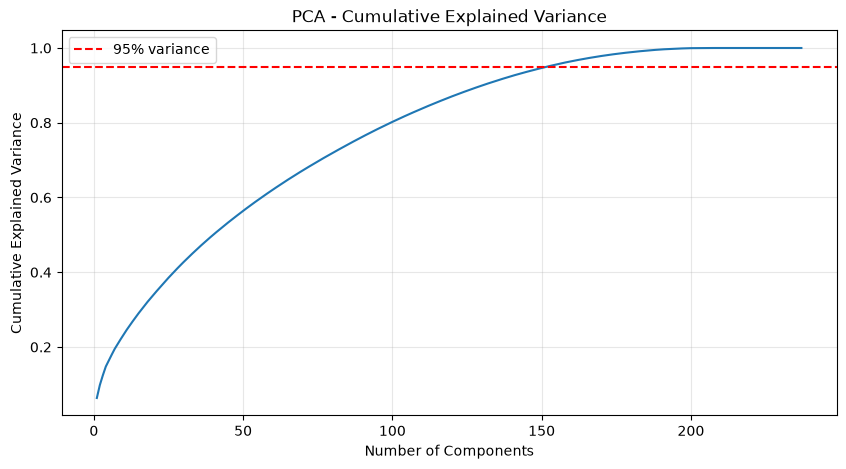

In [188]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()